# 1. Lobster thermal habitat
### This code calculates the area of lobster thermal habitat at seafloor using GLORYS reanalysis data
### The lobster thermal habitat is defined as the area at the seafloor with temperature less than or equal to 20C
# 2. Cold Pool Volume and Duration
### This code calculates the volume and duration of the cold pool within the NYB using GLORYS reanalysis data
### The cold pool is defined as the volume of water bounded by the 10C isotherm and the 34 psu contour

   
#### *This code was created by L. Gruenburg and last edited on May 24 2024
### The glorys reanalysis dataset can be downloaded from copernicus marine services.  I would reccomend you double check this site before these indicators are calculated to see if a more updated data product is available.  The website requires you to create an account and login but it is very quick and easy.

## https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/description


In [1]:
# import relevant packages
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import xarray as xr
import cartopy
import pandas as pn
from datetime import datetime
#import gsw
#from holteandtalley import HolteAndTalley
import os
#from xmovie import Movie
from shapely.geometry import Polygon, Point, MultiPolygon
import shapefile
import geopandas as gpd
import cartopy
import cartopy.crs as ccrs
import math
import scipy.interpolate as sio

In [2]:
# Open the glorys data.  It was too large to download all at once so is split into 2 datasets which will be merged together
glorys1 = xr.open_dataset('/Users/nyelab/Desktop/NYB Indicators/global-reanalysis-phy-001-030-monthly_1630441480776.nc')

In [3]:
glorys2 = xr.open_dataset('/Users/nyelab/Desktop/NYB Indicators/global-reanalysis-phy-001-030-monthly_1630526463376.nc')

In [4]:
# 2022 update - 2020 data now available
glorys3 = xr.open_dataset('/Users/nyelab/Desktop/NYB Indicators/cmems_mod_glo_phy_my_0.083_P1M-m_1671121556932.nc')

In [5]:
#2020 - 2023 update (analysis dataset) for bottom temperature
glorys4 = xr.open_dataset('/Users/nyelab/Downloads/cmems_mod_glo_phy_anfc_0.083deg_P1M-m_1704296554567.nc')

In [6]:
glorys4 = glorys4.rename_vars({'tob': 'bottomT'})

In [7]:
#2020-2023 update (Analysis) for full depth potential temperature
glorys5 = xr.open_dataset('/Users/nyelab/Downloads/cmems_mod_glo_phy-thetao_anfc_0.083deg_P1M-m_1704383384762.nc')

In [8]:
#2020-2023 update (Analysis) for full depth salinity
glorys5salt = xr.open_dataset('/Users/nyelab/Downloads/cmems_mod_glo_phy-so_anfc_0.083deg_P1M-m_1704383744052.nc')

In [9]:
glorys1.depth

<xarray.DataArray 'depth' (depth: 41)>
array([4.940250e-01, 1.541375e+00, 2.645669e+00, 3.819495e+00, 5.078224e+00,
       6.440614e+00, 7.929560e+00, 9.572997e+00, 1.140500e+01, 1.346714e+01,
       1.581007e+01, 1.849556e+01, 2.159882e+01, 2.521141e+01, 2.944473e+01,
       3.443415e+01, 4.034405e+01, 4.737369e+01, 5.576429e+01, 6.580727e+01,
       7.785385e+01, 9.232607e+01, 1.097293e+02, 1.306660e+02, 1.558507e+02,
       1.861256e+02, 2.224752e+02, 2.660403e+02, 3.181274e+02, 3.802130e+02,
       4.539377e+02, 5.410889e+02, 6.435668e+02, 7.633331e+02, 9.023393e+02,
       1.062440e+03, 1.245291e+03, 1.452251e+03, 1.684284e+03, 1.941893e+03,
       2.225078e+03], dtype=float32)
Coordinates:
  * depth    (depth) float32 0.494 1.541 2.646 ... 1.684e+03 1.942e+03 2.225e+03
Attributes:
    valid_min:               0.494025
    valid_max:               2225.078
    units:                   m
    positive:                down
    unit_long:               Meters
    long_name:               Depth
    standard_name:           depth
    axis:                    Z
    _ChunkSizes:             50
    _CoordinateAxisType:     Height
    _CoordinateZisPositive:  down

## This part is to make sure the updated timeseries can fit with the previous ones.  THIS MAY BECOME UNNECESSARY (The next 4 cells), double check the available data first.

In [9]:
glorys4cut = glorys4.sel(time = slice(glorys4.time[2], glorys4.time[36]))

glorys4_recoord = xr.Dataset(data_vars = {'bottomT': (['time', 'latitude', 'longitude'], glorys4cut.bottomT.values)},
                            coords = {'time': glorys4cut.time.values,
                                     'latitude': glorys3.latitude.values,
                                     'longitude': glorys3.longitude.values})

In [10]:
glorys4_recoord

<xarray.Dataset>
Dimensions:    (time: 35, latitude: 73, longitude: 241)
Coordinates:
  * time       (time) datetime64[ns] 2021-01-16T12:00:00 ... 2023-11-16
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
Data variables:
    bottomT    (time, latitude, longitude) float32 nan nan nan ... 1.845 1.84

In [11]:
glorys5cut = glorys5.sel(time = slice(glorys5.time[2], glorys5.time[36]))

glorys5_recoord = xr.Dataset(data_vars = {'thetao': (['time','depth', 'latitude', 'longitude'], glorys5cut.thetao.values)},
                            coords = {'time': glorys5cut.time.values,
                                      'depth':glorys5cut.depth.values,
                                     'latitude': glorys3.latitude.values,
                                     'longitude': glorys3.longitude.values})

In [12]:
glorys5cut_salt = glorys5salt.sel(time = slice(glorys5salt.time[2], glorys5salt.time[36]))

glorys5_recoord_salt = xr.Dataset(data_vars = {'so': (['time','depth', 'latitude', 'longitude'], glorys5cut_salt.so.values)},
                            coords = {'time': glorys5cut_salt.time.values,
                                      'depth':glorys5cut_salt.depth.values,
                                     'latitude': glorys3.latitude.values,
                                     'longitude': glorys3.longitude.values})

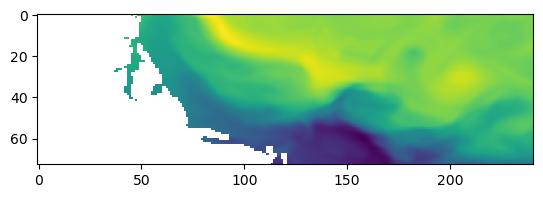

In [13]:
# Make a simple temperature plot just to see what it looks like
plt.imshow(glorys2.thetao[20,0,:,:])

In [14]:
glorys5cut.latitude

<xarray.DataArray 'latitude' (latitude: 73)>
array([36.      , 36.083336, 36.16667 , 36.25    , 36.333336, 36.41667 ,
       36.5     , 36.583336, 36.66667 , 36.75    , 36.833336, 36.91667 ,
       37.      , 37.083336, 37.16667 , 37.25    , 37.333336, 37.41667 ,
       37.5     , 37.583336, 37.66667 , 37.75    , 37.833336, 37.91667 ,
       38.      , 38.083336, 38.16667 , 38.25    , 38.333336, 38.41667 ,
       38.5     , 38.583336, 38.66667 , 38.75    , 38.833336, 38.91667 ,
       39.      , 39.083336, 39.16667 , 39.25    , 39.333336, 39.41667 ,
       39.5     , 39.583336, 39.66667 , 39.75    , 39.833336, 39.91667 ,
       40.      , 40.083336, 40.16667 , 40.25    , 40.333336, 40.41667 ,
       40.5     , 40.583336, 40.66667 , 40.75    , 40.833336, 40.91667 ,
       41.      , 41.083336, 41.16667 , 41.25    , 41.333336, 41.41667 ,
       41.5     , 41.583336, 41.66667 , 41.75    , 41.833336, 41.91667 ,
       42.      ], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
Attributes:
    valid_min:            36.0
    valid_max:            42.0
    step:                 0.08333588
    units:                degrees_north
    unit_long:            Degrees North
    long_name:            Latitude
    standard_name:        latitude
    axis:                 Y
    _ChunkSizes:          2041
    _CoordinateAxisType:  Lat

In [15]:
glorys4cut.latitude

<xarray.DataArray 'latitude' (latitude: 73)>
array([36.      , 36.083336, 36.16667 , 36.25    , 36.333336, 36.41667 ,
       36.5     , 36.583336, 36.66667 , 36.75    , 36.833336, 36.91667 ,
       37.      , 37.083336, 37.16667 , 37.25    , 37.333336, 37.41667 ,
       37.5     , 37.583336, 37.66667 , 37.75    , 37.833336, 37.91667 ,
       38.      , 38.083336, 38.16667 , 38.25    , 38.333336, 38.41667 ,
       38.5     , 38.583336, 38.66667 , 38.75    , 38.833336, 38.91667 ,
       39.      , 39.083336, 39.16667 , 39.25    , 39.333336, 39.41667 ,
       39.5     , 39.583336, 39.66667 , 39.75    , 39.833336, 39.91667 ,
       40.      , 40.083336, 40.16667 , 40.25    , 40.333336, 40.41667 ,
       40.5     , 40.583336, 40.66667 , 40.75    , 40.833336, 40.91667 ,
       41.      , 41.083336, 41.16667 , 41.25    , 41.333336, 41.41667 ,
       41.5     , 41.583336, 41.66667 , 41.75    , 41.833336, 41.91667 ,
       42.      ], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
Attributes:
    valid_min:            36.0
    valid_max:            42.0
    step:                 0.08333588
    units:                degrees_north
    unit_long:            Degrees North
    long_name:            Latitude
    standard_name:        latitude
    axis:                 Y
    _ChunkSizes:          2041
    _CoordinateAxisType:  Lat

In [16]:
glorys1.latitude.round(3)

<xarray.DataArray 'latitude' (latitude: 73)>
array([36.   , 36.083, 36.167, 36.25 , 36.333, 36.417, 36.5  , 36.583,
       36.667, 36.75 , 36.833, 36.917, 37.   , 37.083, 37.167, 37.25 ,
       37.333, 37.417, 37.5  , 37.583, 37.667, 37.75 , 37.833, 37.917,
       38.   , 38.083, 38.167, 38.25 , 38.333, 38.417, 38.5  , 38.583,
       38.667, 38.75 , 38.833, 38.917, 39.   , 39.083, 39.167, 39.25 ,
       39.333, 39.417, 39.5  , 39.583, 39.667, 39.75 , 39.833, 39.917,
       40.   , 40.083, 40.167, 40.25 , 40.333, 40.417, 40.5  , 40.583,
       40.667, 40.75 , 40.833, 40.917, 41.   , 41.083, 41.167, 41.25 ,
       41.333, 41.417, 41.5  , 41.583, 41.667, 41.75 , 41.833, 41.917,
       42.   ], dtype=float32)
Coordinates:
  * latitude  (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
Attributes:
    valid_min:            36.0
    valid_max:            42.0
    step:                 0.08333588
    units:                degrees_north
    unit_long:            Degrees North
    long_name:            Latitude
    standard_name:        latitude
    axis:                 Y
    _ChunkSizes:          2041
    _CoordinateAxisType:  Lat

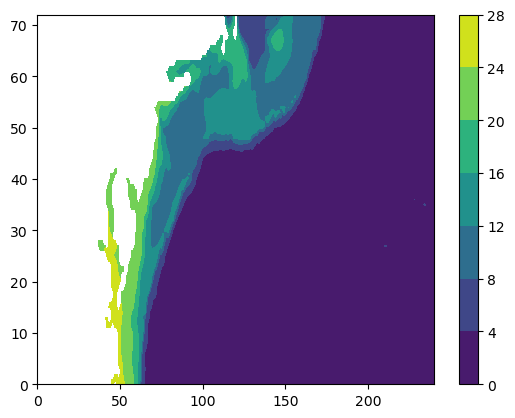

In [17]:
# Make another simple plot oriented with north up for easier understanding
c = plt.contourf(glorys2.bottomT[20,:,:])
#c = plt.contour(glorys2.bottomT[20,:,:],levels = 10,colors = 'k')
plt.colorbar(c)

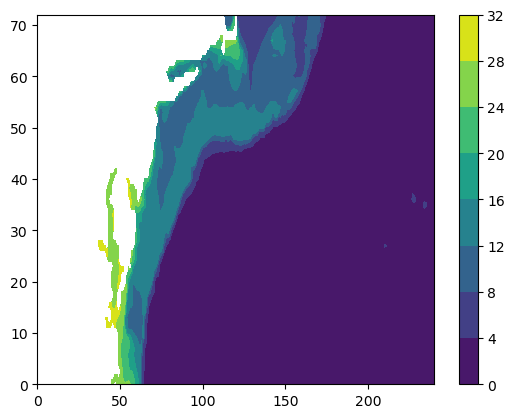

In [18]:
c = plt.contourf(glorys4.bottomT[20,:,:])
plt.colorbar(c)

In [19]:
# Merge the 2 datasets into one
glorysBT = xr.merge([glorys1.bottomT,glorys2.bottomT,glorys3.bottomT,glorys4_recoord.bottomT])

In [20]:
# Merge the 2 datasets into one
glorys = xr.merge([glorys1.thetao,glorys2.thetao,glorys3.thetao,glorys5_recoord.thetao])

In [21]:
# Merge the 2 datasets into one
glorys_salt = xr.merge([glorys1.so,glorys2.so,glorys3.so,glorys5_recoord_salt.so])

In [22]:
# See what the dataset looks like
glorys1



<xarray.Dataset>
Dimensions:    (time: 144, latitude: 73, longitude: 241, depth: 41)
Coordinates:
  * depth      (depth) float32 0.494 1.541 2.646 ... 1.942e+03 2.225e+03
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
  * time       (time) datetime64[ns] 1993-01-16T12:00:00 ... 2004-12-16T12:00:00
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
Data variables:
    mlotst     (time, latitude, longitude) float32 ...
    vo         (time, depth, latitude, longitude) float32 ...
    thetao     (time, depth, latitude, longitude) float32 ...
    uo         (time, depth, latitude, longitude) float32 ...
    bottomT    (time, latitude, longitude) float32 ...
    so         (time, depth, latitude, longitude) float32 ...
    zos        (time, latitude, longitude) float32 ...
Attributes: (12/17)
    title:                         Monthly mean fields for product GLOBAL_REA...
    references:                    http://marine.copernicus.eu
    credit:                        E.U. Copernicus Marine Service Information...
    licence:                       http://marine.copernicus.eu/services-portf...
    contact:                       servicedesk.cmems@mercator-ocean.eu
    producer:                      CMEMS - Global Monitoring and Forecasting ...
    ...                            ...
    source:                        MERCATOR GLORYS12V1
    product_user_manual:           http://marine.copernicus.eu/documents/PUM/...
    quality_information_document:  http://marine.copernicus.eu/documents/QUID...
    _CoordSysBuilder:              ucar.nc2.dataset.conv.CF1Convention
    comment:                       
    history:                       Data extracted from dataset http://localho...

In [21]:
glorys4.time[36]

<xarray.DataArray 'time' ()>
array('2023-11-16T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-11-16
Attributes:
    long_name:            Time (hours since 1950-01-01)
    standard_name:        time
    axis:                 T
    _ChunkSizes:          1024
    _CoordinateAxisType:  Time
    valid_min:            621288.0
    valid_max:            647568.0

In [23]:
# Load NYB shapefile
NYB = gpd.read_file('/Users/nyelab/Desktop/NYB Indicators/Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp')

In [24]:
# Alter the projection to WGS84 see https://epsg.io/4326
NYB = NYB.to_crs(epsg=4326)

In [25]:
# Extract the polygon
nyb_shape = NYB.geometry[0]

In [26]:
# Function that checks if the points are within the NYB (variable with depth - FOR COLD POOL)
def inNYB(longitude, latitude, time, depth, var, shape):
    X = longitude
    Y = latitude
    x, y = np.meshgrid(X, Y)
    empty = np.empty([len(time), len(depth), len(latitude), len(longitude)])
    empty[:,:,:,:] = np.nan
    for i in range(len(latitude)):
        for j in range(len(longitude)):
            if Point(x[i,j], y[i,j]).within(shape) == True:
                empty[:,:,i,j] = var[:,:,i,j]
    return empty

In [27]:
#subset of glorys pot temp for just the NYB (FOR COLD POOL)
glorys_nyb_theta = inNYB(glorys.longitude,glorys.latitude,glorys.time,glorys.depth, glorys.thetao, nyb_shape)

In [28]:
#subset of glorys salinity for just the NYB (FOR COLD POOL)
glorys_nyb_salt = inNYB(glorys_salt.longitude,glorys_salt.latitude,glorys_salt.time,glorys_salt.depth, glorys_salt.so, nyb_shape)

In [29]:
# Function that checks if the points are within the NYB (variable without depth - FOR LOBSTER THERMAL HABITAT)
def inNYB_nodepth(longitude, latitude, time, var, shape):
    X = longitude
    Y = latitude
    x, y = np.meshgrid(X, Y)
    empty = np.empty([len(time), len(latitude), len(longitude)])
    empty[:,:,:] = np.nan
    for i in range(len(latitude)):
        for j in range(len(longitude)):
            if Point(x[i,j], y[i,j]).within(shape) == True:
                empty[:,i,j] = var[:,i,j]
    return empty

In [30]:
#subset of glorys bottom temp for just the NYB (FOR LOBSTER THERMAL HABITAT)
glorys_nyb_bot_t = inNYB_nodepth(glorysBT.longitude,glorysBT.latitude,glorysBT.time, glorysBT.bottomT, nyb_shape)

In [31]:
# Reanalysis data is at a quarter of a degree, but the absolute distance changes with latitude.  This calculates those distances.
lon_at_lat = np.empty(73) 
lon_at_lat[:] = np.nan
for i in range(73): 
    lon_at_lat[i] = (1/12) * math.cos(np.radians(glorys.latitude[i])) * 111.3

In [32]:
# Difference between degrees of latitude roughly the same
lat_diff = 110*(1/12)
lat_diff

9.166666666666666

In [32]:
# 1/12 degree is approximately 7km
(1/12) * math.cos(np.radians(glorys.latitude[i])) * 111.3

6.892668129705014

In [33]:
# See what the areas of the boxes will be like
lon_at_lat*lat_diff

array([68.78329817, 68.71054262, 68.63763874, 68.56459266, 68.49140153,
       68.41806252, 68.34458179, 68.27095346, 68.19718071, 68.12326672,
       68.04920862, 67.97500354, 67.90065771, 67.82616824, 67.75152918,
       67.67675292, 67.60183349, 67.52676799, 67.45156272, 67.37621477,
       67.3007212 , 67.22508525, 67.14931021, 67.07339   , 66.99733102,
       66.92113032, 66.84478493, 66.76830127, 66.69167637, 66.6149041 ,
       66.53799721, 66.46094956, 66.38375816, 66.30642951, 66.22896059,
       66.15134839, 66.07359625, 65.99570753, 65.917676  , 65.83950824,
       65.7612012 , 65.68275184, 65.60416675, 65.52543966, 65.44657395,
       65.36757302, 65.28843383, 65.20915328, 65.12973803, 65.05018502,
       64.97048787, 64.89065981, 64.81069448, 64.73058878, 64.65034943,
       64.56997332, 64.48945732, 64.40880821, 64.32801954, 64.24709478,
       64.16603743, 64.08484435, 64.00351238, 63.92204835, 63.8404491 ,
       63.75870811, 63.67683894, 63.59483507, 63.51269331, 63.43

In [34]:
# Want a 2D array for area
lons, area = np.meshgrid(glorysBT.longitude, lon_at_lat*lat_diff)

In [35]:
len(glorys.latitude)

73

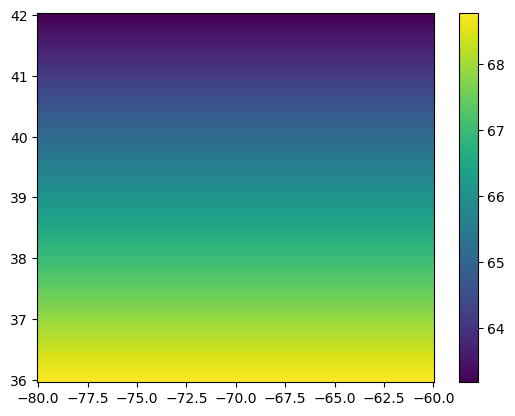

In [36]:
# Visualize the areas in lat lon space.  Notice larger area at the south smaller to the north - as expected!
c = plt.pcolor(glorysBT.longitude, glorysBT.latitude, area)
plt.colorbar(c)

## Lobster Thermal Habitat

In [37]:
# Doing a quick test on the first time step
subset = glorys_nyb_bot_t[0,:,:]

In [38]:
# Quick test on that first time step to see if the area less than or equal to 20C is working
subset[np.where(glorys_nyb_bot_t[0,:,:]<=20)]
Area = np.sum(area[np.where(glorys_nyb_bot_t[0,:,:]<=20)])
Area

42776.96407357517

In [39]:
len(glorys.time)

371

In [40]:
# Loop through each month and calculate the area at each time step
Area = np.empty(371) # update here for adding another year of data
Area[:] = np.nan
for i in range(371):
    Area[i] = np.sum(area[np.where(glorys_nyb_bot_t[i,:,:]<=20)])

In [41]:
bott_subset_seas = glorysBT.bottomT.groupby('time.season').mean('time')

In [42]:
glorys

<xarray.Dataset>
Dimensions:    (depth: 41, latitude: 73, time: 371, longitude: 241)
Coordinates:
  * depth      (depth) float32 0.494 1.541 2.646 ... 1.942e+03 2.225e+03
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
  * time       (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-11-16
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 nan nan ... nan nan
Attributes:
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    units:          degrees_C
    unit_long:      Degrees Celsius
    cell_methods:   area: mean
    _ChunkSizes:    [  1   7 341 720]

In [44]:
plt.plot([ad_lon_t, liv_lon_t], [ad_lat_t, liv_lat_t],
         color='blue', linewidth=1, marker='o', markersize=3,
         # Be explicit about which transform you want:
         transform=robinson)

NameError: name 'ad_lon_t' is not defined

NameError: name 'JJA' is not defined

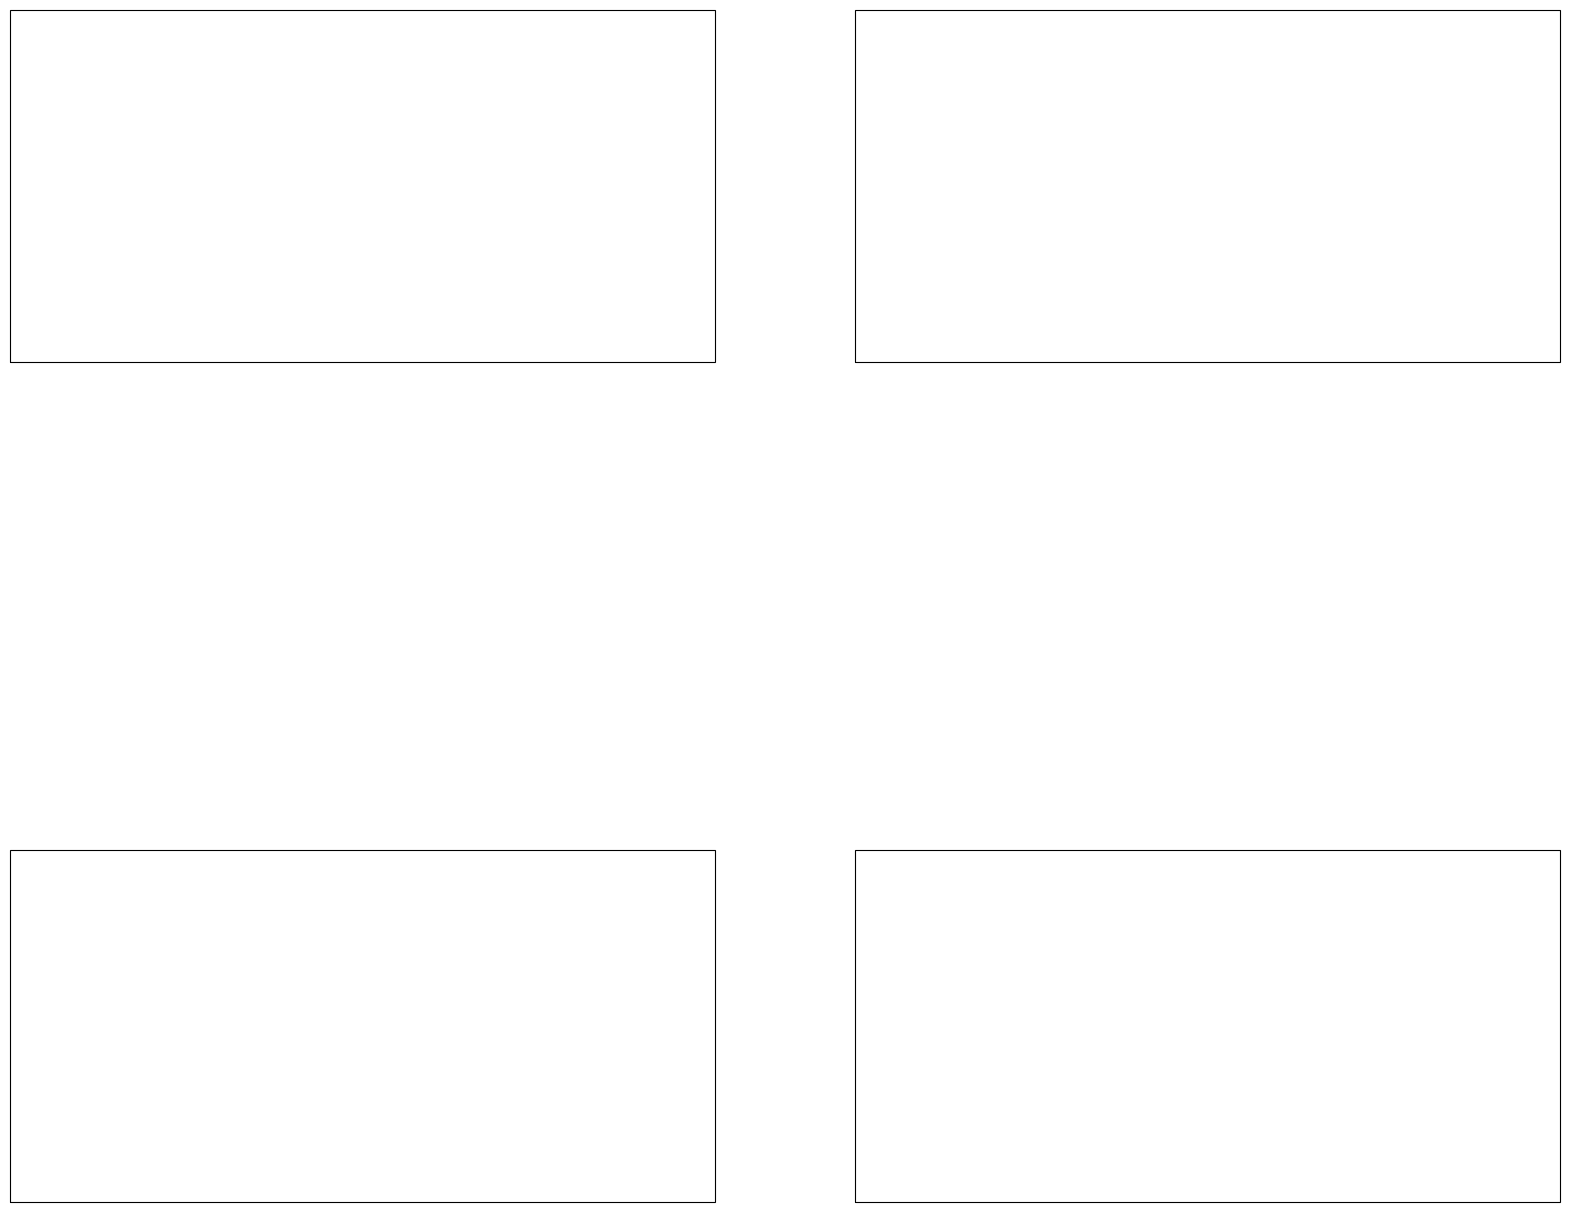

In [45]:
fig,ax = plt.subplots(ncols = 2, nrows = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
for i in range(len(JJA)-1):
    if np.nanmax(sst_seas[JJA[i],:,:]) >= 20:
        text = np.arange(1982,2022,1)
        text2 = str(text[i])
        if text[i]<1990:
            extent = [286,289.5,38.25,41.5]
            gl = ax[0,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=2, color='gray', alpha=0.05, linestyle='--')
            gl.xlabels_top = False
            gl.xlabels_bottom = False
            gl.ylabels_right = False
            gl.ylabel_style = {'size': 20, 'color': 'k'}
            ax[0,0].set_extent(extent)
            ax[0,0].coastlines(resolution='10m')
            CS = ax[0,0].contour(sst.longitude[25:40],sst.latitude,sst_seas[JJA[i],:,25:40],levels = [20],colors='r',linewidths = 2.5,transform=ccrs.PlateCarree())
            ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[1,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
            ax[0,0].clabel(CS, fontsize=20, inline=1, fmt=text2)
            #ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
            ax[0,0].add_geometries(NYB.geometry,
                  ccrs.PlateCarree(),
                  facecolor='none', edgecolor = 'k')#hatch='xxxx')

/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


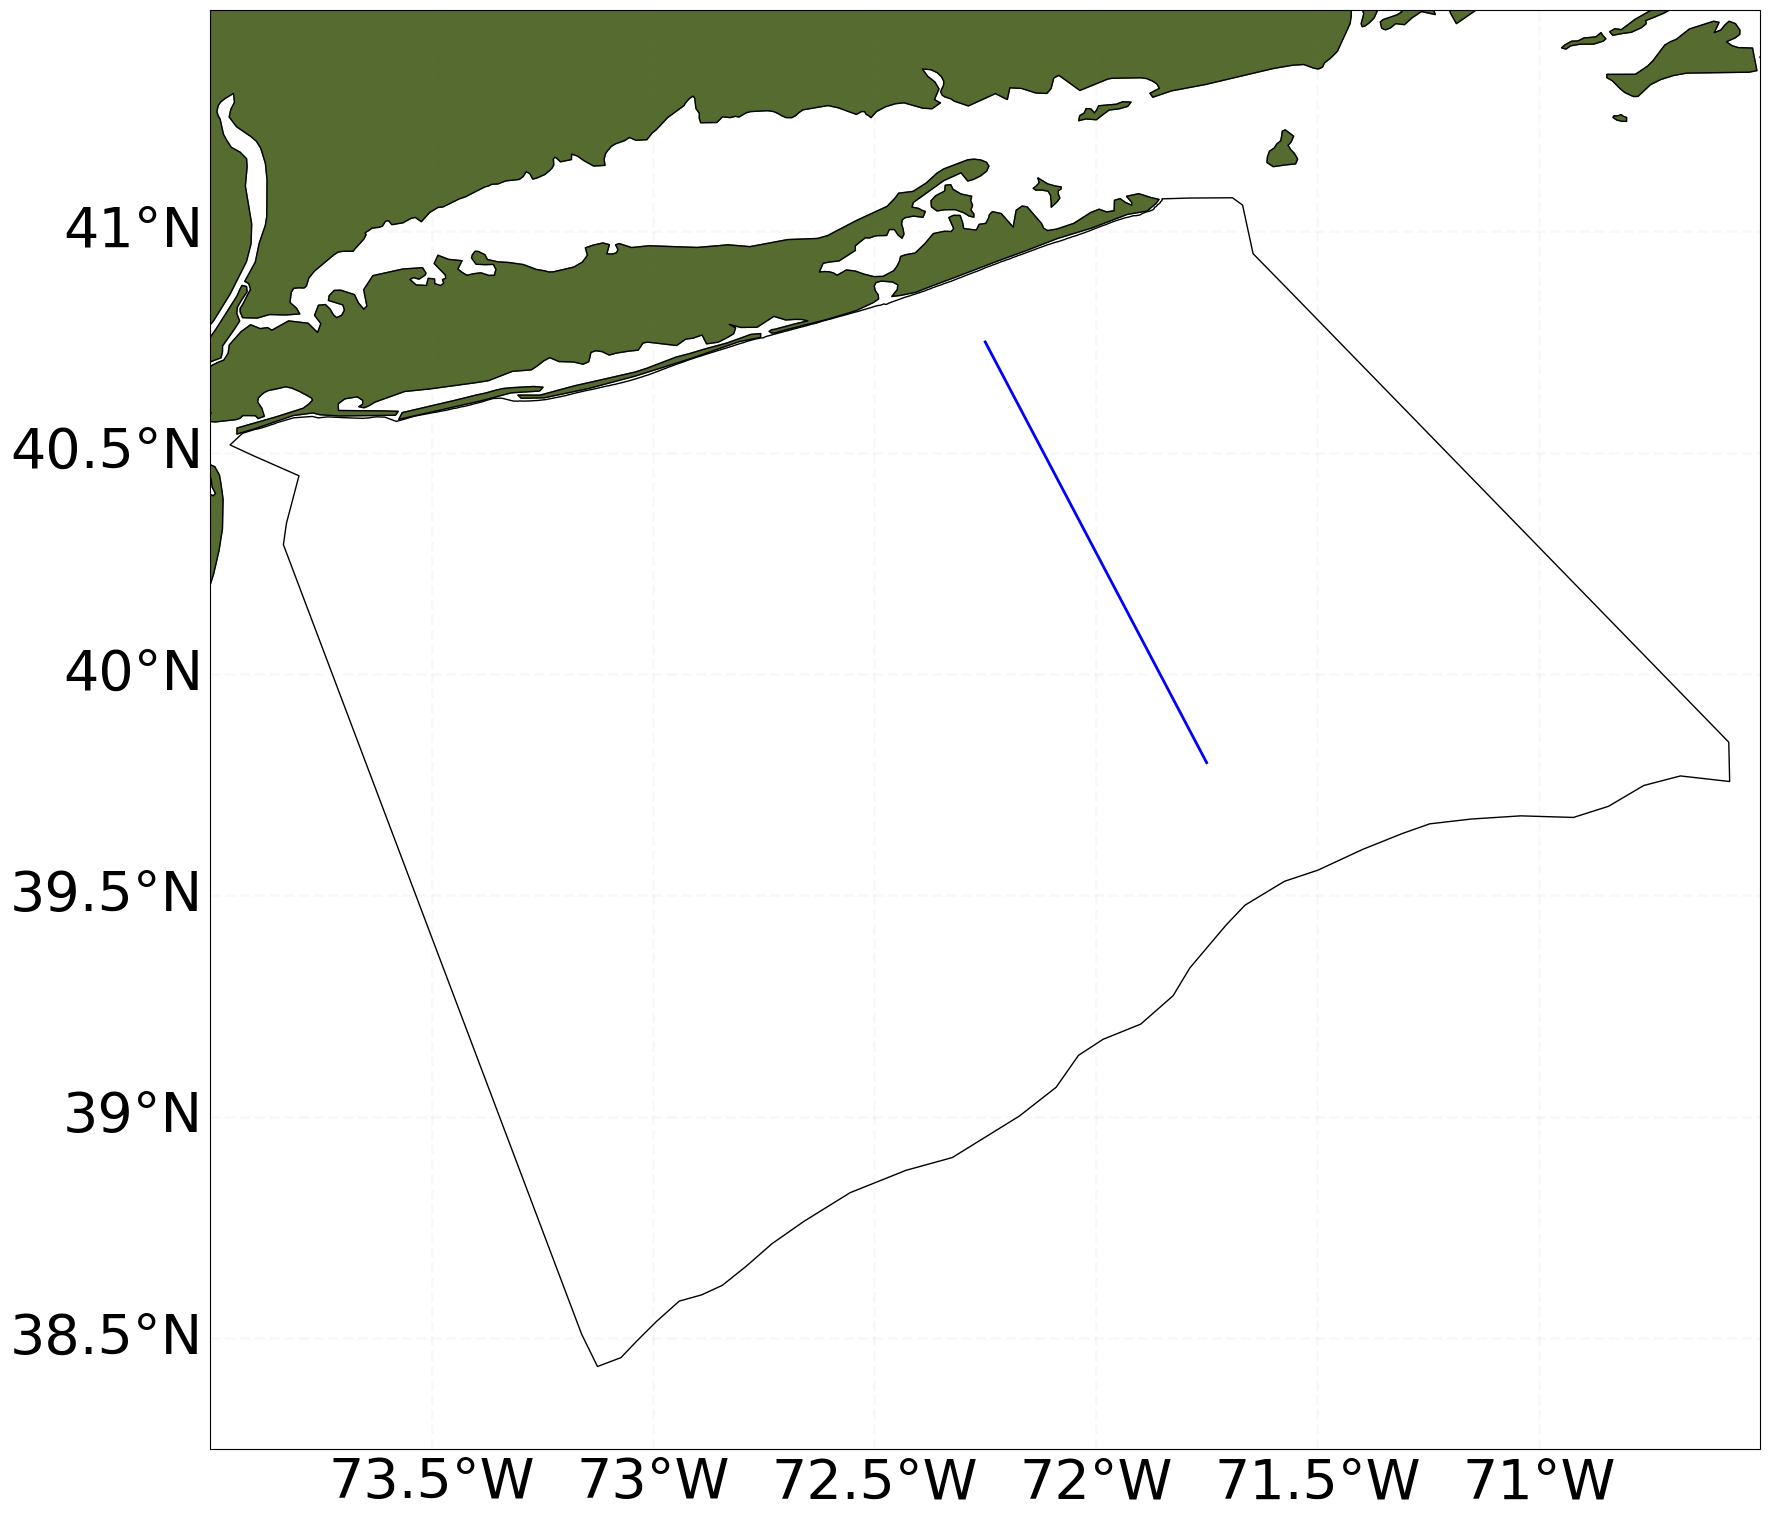

In [46]:
%matplotlib inline
fig,ax = plt.subplots(figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 40, 'color': 'k'}
gl.xlabel_style = {'size': 40, 'color': 'k'}
ax.set_extent(extent)
ax.coastlines(resolution='10m')
#CS = ax.contourf(glorysBT.longitude,glorysBT.latitude,bott_subset_seas[2,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax.contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax.clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax.clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax.add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
ax.plot([-71.75, -72.25], [39.8, 40.75], color = 'blue',
       linewidth = 2, transform = ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, color = 'darkolivegreen')
            #ax.set_title('20C isotherm surface SON 1982-1989', fontsize = 20)

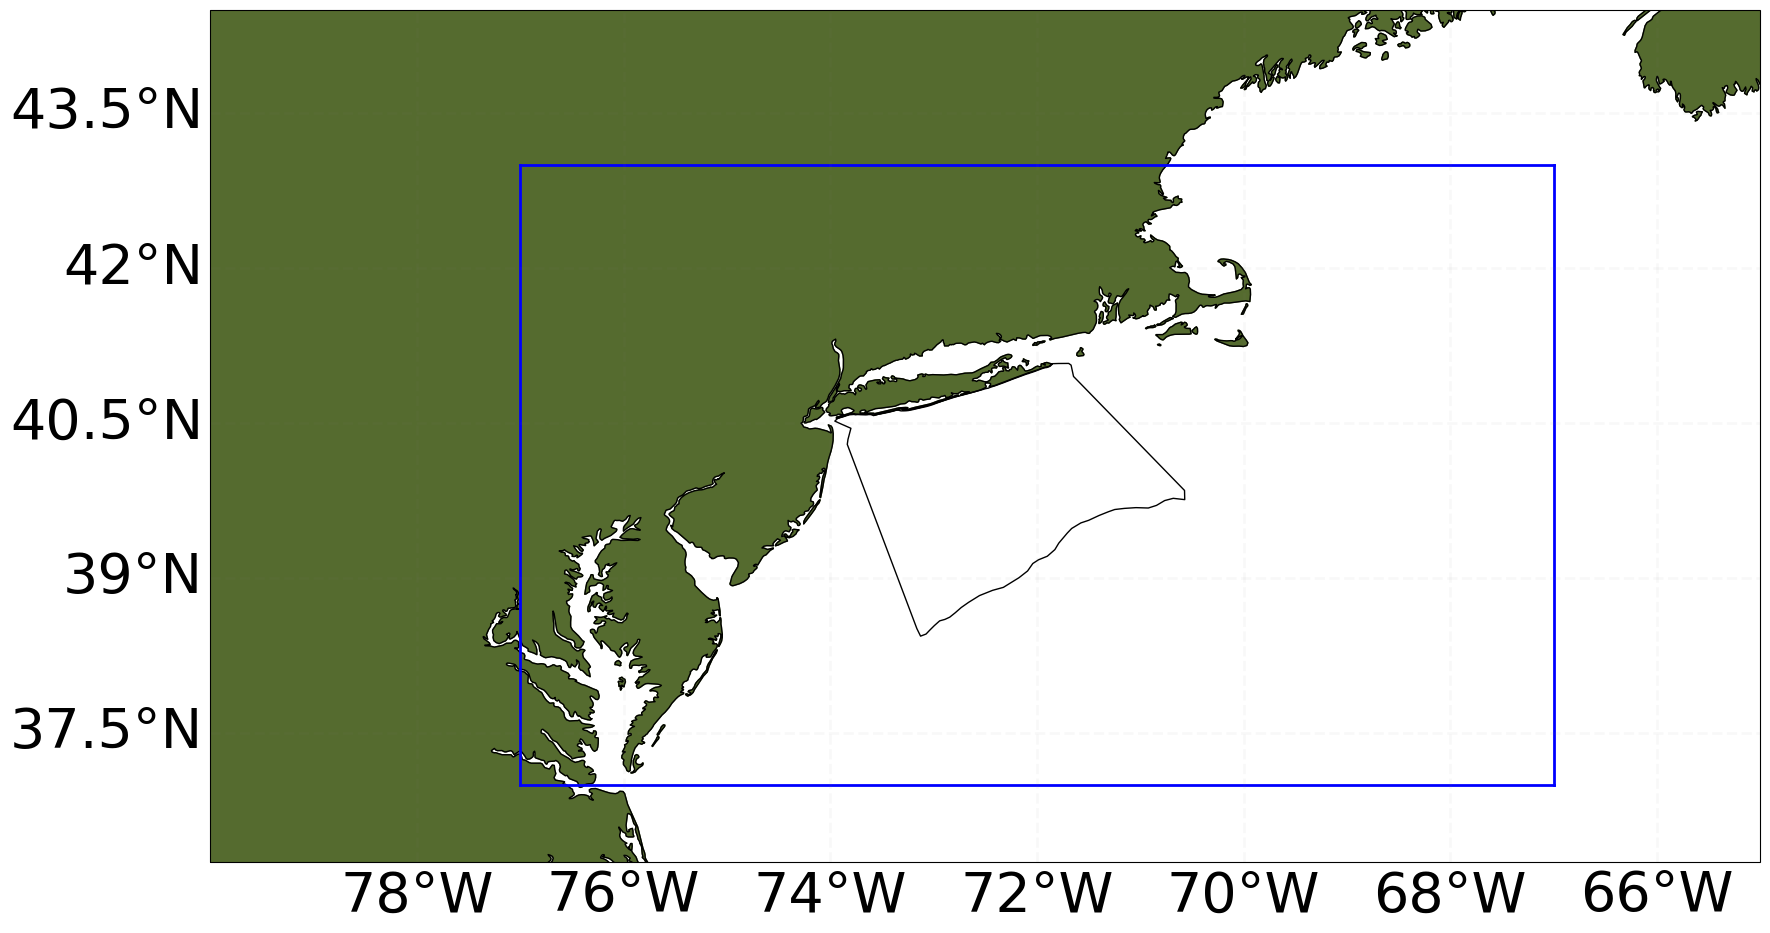

In [47]:
%matplotlib inline
fig,ax = plt.subplots(figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [280,295,36.25,44.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 40, 'color': 'k'}
gl.xlabel_style = {'size': 40, 'color': 'k'}
ax.set_extent(extent)
ax.coastlines(resolution='10m')
#CS = ax.contourf(glorysBT.longitude,glorysBT.latitude,bott_subset_seas[2,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax.contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax.clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax.clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax.add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
ax.plot([-77, -77], [37, 43], color = 'blue',
       linewidth = 2, transform = ccrs.PlateCarree())
ax.plot([-67, -67], [37, 43], color = 'blue',
       linewidth = 2, transform = ccrs.PlateCarree())
ax.plot([-77, -67], [43, 43], color = 'blue',
       linewidth = 2, transform = ccrs.PlateCarree())
ax.plot([-77, -67], [37, 37], color = 'blue',
       linewidth = 2, transform = ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, color = 'darkolivegreen')
            #ax.set_title('20C isotherm surface SON 1982-1989', fontsize = 20)

In [48]:
waypoints = pn.read_csv('/Users/nyelab/Downloads/nyos_station_list.csv')

In [49]:
waypoints67 = waypoints[waypoints.Waypoint >=6]
waypoints6 = waypoints67[waypoints67.Waypoint < 7]
waypoints6

,Waypoint,Type,Depth,LON,LAT,Transect
27,6.1,CTD,-19.430363,-73.451237,40.514641,6
28,6.2,CTD,-41.398098,-73.324238,40.169191,6
29,6.3,CTD-PLUME,-45.021019,-73.197239,39.823742,6
30,6.4,CTD-PLUME,-66.923309,-73.070240,39.478292,6
31,6.5,CTD,-81.326416,-72.943241,39.132842,6
32,6.6,CTD,-1392.581700,-72.816243,38.787392,6


In [50]:
waypoints8 = pn.read_csv('/Users/nyelab/Downloads/nyos_station_2023.csv')
waypoints8

,Waypoint,Latitude,Longitude
0,8.1,40.569722,-73.405833
1,8.2,40.301389,-73.220833
2,8.3,40.080000,-73.070000
3,8.4,39.841389,-72.907500
4,8.5,39.602222,-72.746111
5,8.6,39.361667,-72.585278
6,8.7,39.115833,-72.420000


/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


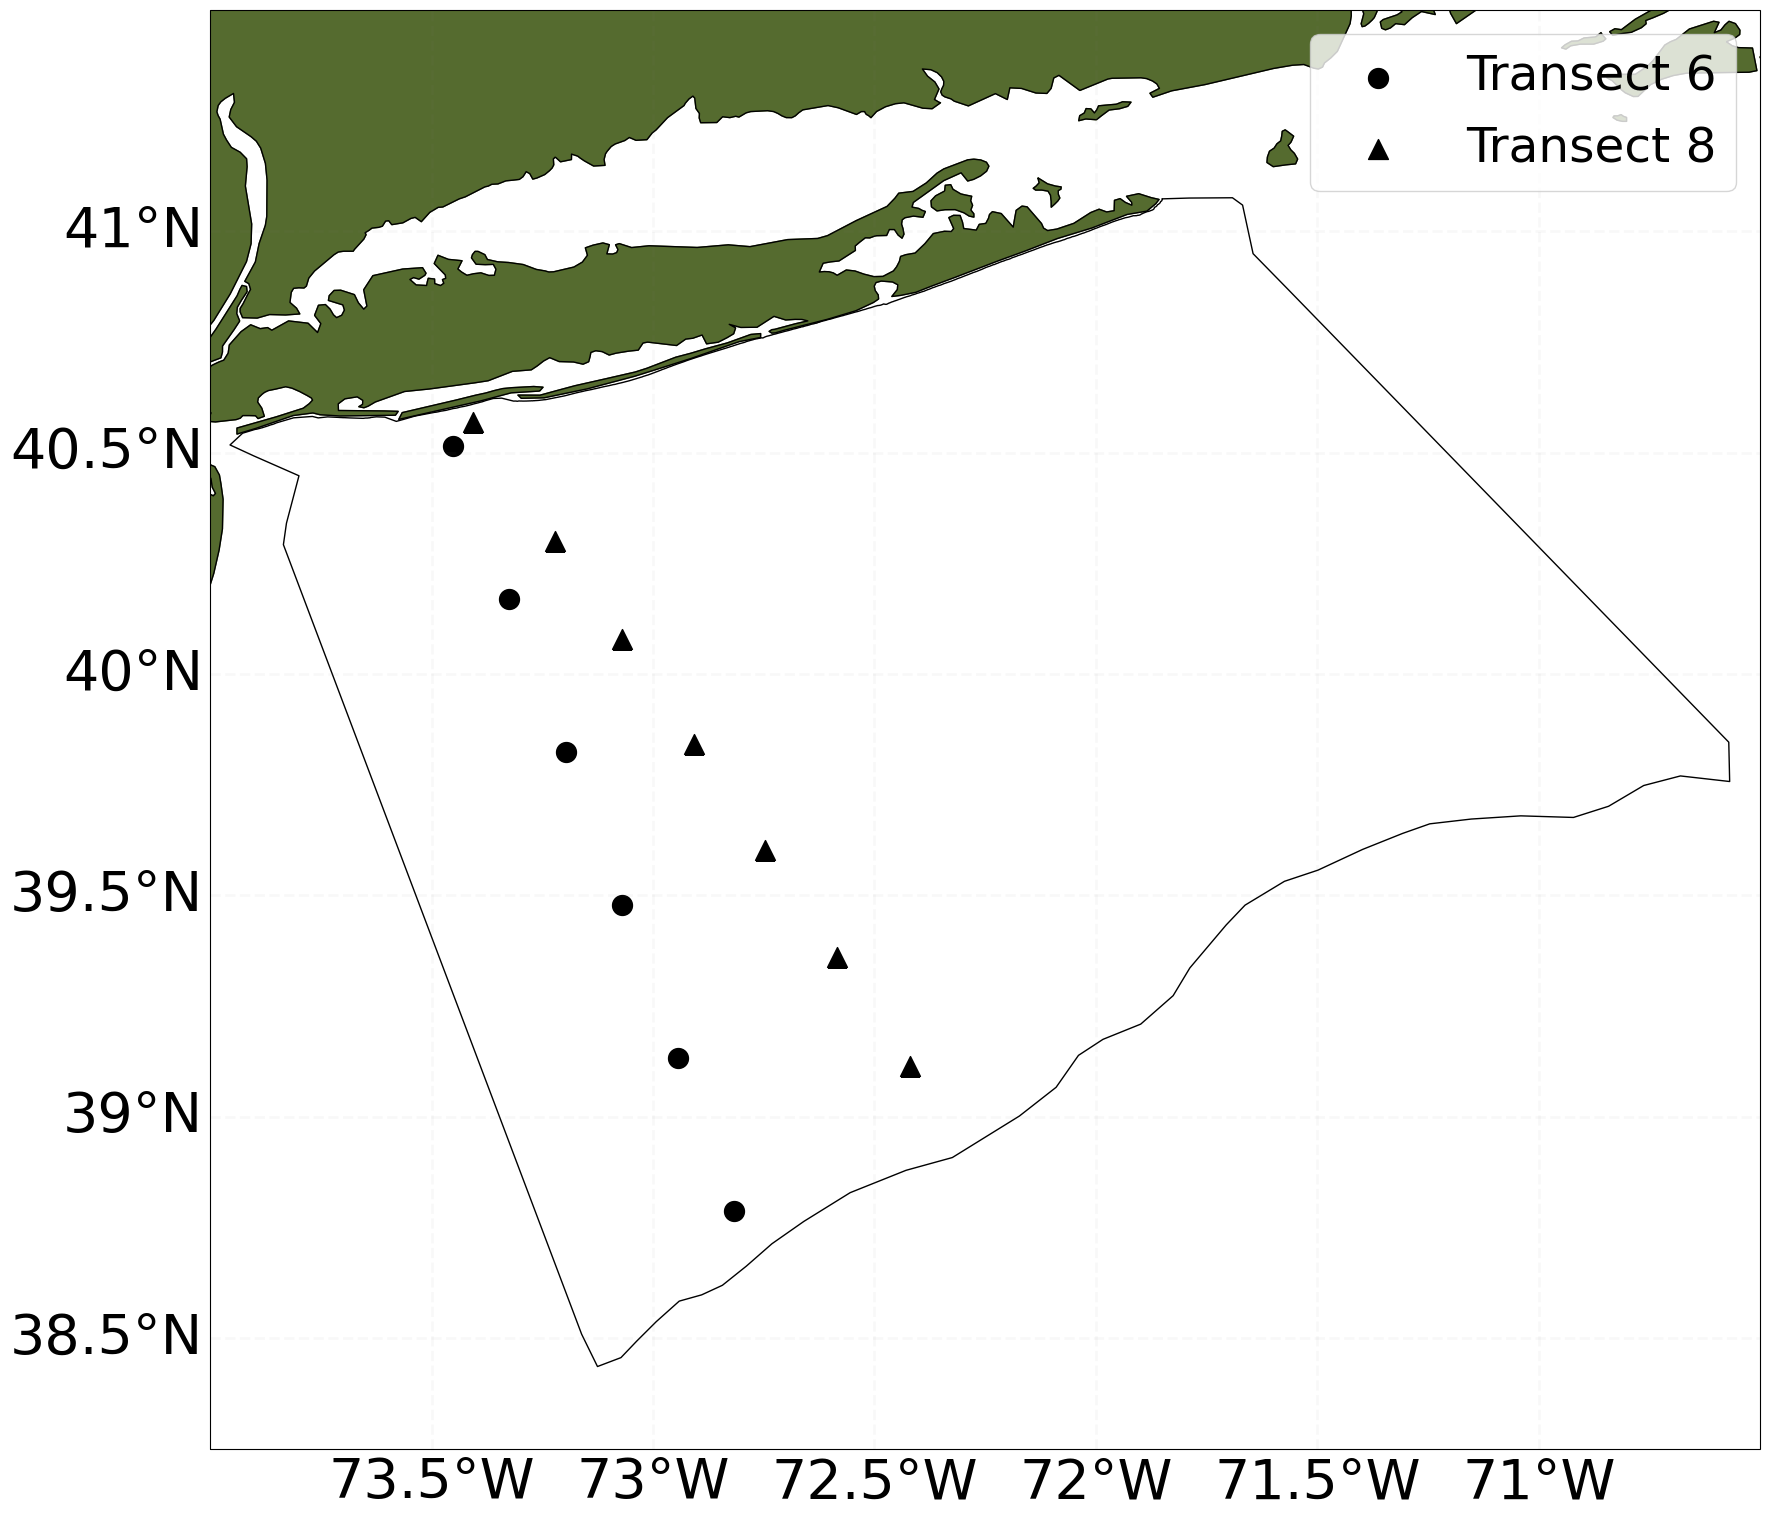

In [51]:
#Plot of waypoints for the offshore cruise
%matplotlib inline
fig,ax = plt.subplots(figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 40, 'color': 'k'}
gl.xlabel_style = {'size': 40, 'color': 'k'}
ax.set_extent(extent)
ax.coastlines(resolution='10m')
#CS = ax.contourf(glorysBT.longitude,glorysBT.latitude,bott_subset_seas[2,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax.contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax.clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax.clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax.add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
ax.scatter(waypoints6.LON, waypoints6.LAT, color = 'black',transform = ccrs.PlateCarree(), s=205, label = "Transect 6")
ax.scatter(waypoints8.Longitude, waypoints8['Latitude '], color = 'black',transform = ccrs.PlateCarree(), s=205, label = "Transect 8", marker = "^")
ax.add_feature(cartopy.feature.LAND, color = 'darkolivegreen')
plt.legend(fontsize = 35)

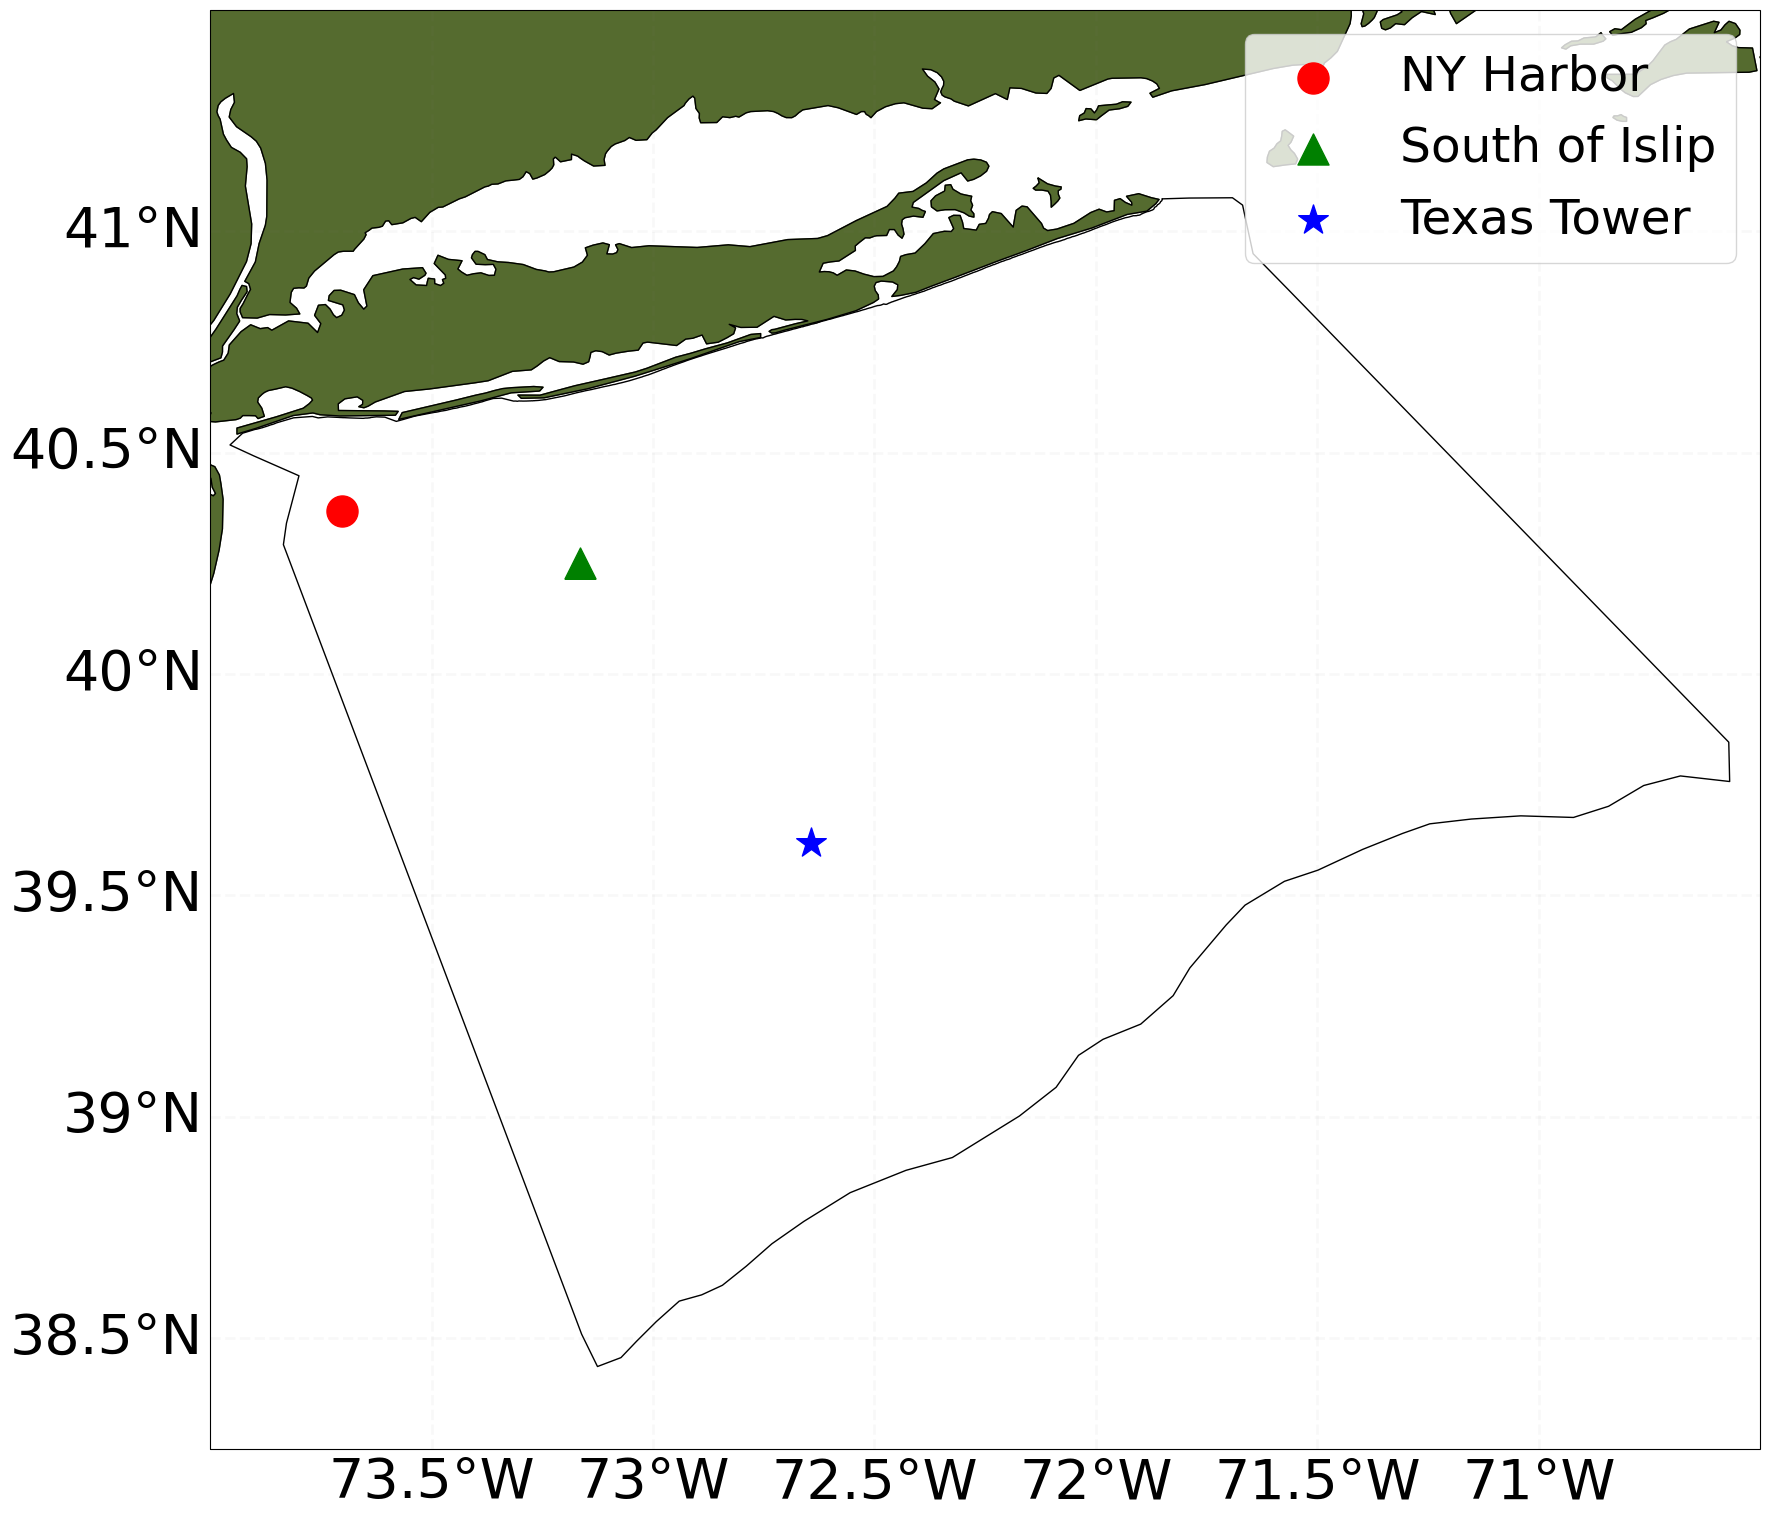

In [52]:
#Plot of the three buoy locations for the windspeed indicator
%matplotlib inline
fig,ax = plt.subplots(figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 40, 'color': 'k'}
gl.xlabel_style = {'size': 40, 'color': 'k'}
ax.set_extent(extent)
ax.coastlines(resolution='10m')
#CS = ax.contourf(glorysBT.longitude,glorysBT.latitude,bott_subset_seas[2,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax.contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax.clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax.clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax.add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
ax.scatter(-73.703, 40.369, color = 'red',transform = ccrs.PlateCarree(), s=500, label = "NY Harbor")
ax.scatter(-73.164, 40.251, color = 'green',transform = ccrs.PlateCarree(), s=500, label = "South of Islip", marker = "^")
ax.scatter(-72.644, 39.618, color = 'blue',transform = ccrs.PlateCarree(), s=500, label = "Texas Tower", marker = "*")
ax.add_feature(cartopy.feature.LAND, color = 'darkolivegreen')
plt.legend(fontsize = 35)

/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecated. Please use .bottom_labels to toggle visibility instead.
  warnings.warn('The .xlabels_bottom attribute is deprecated. Please '


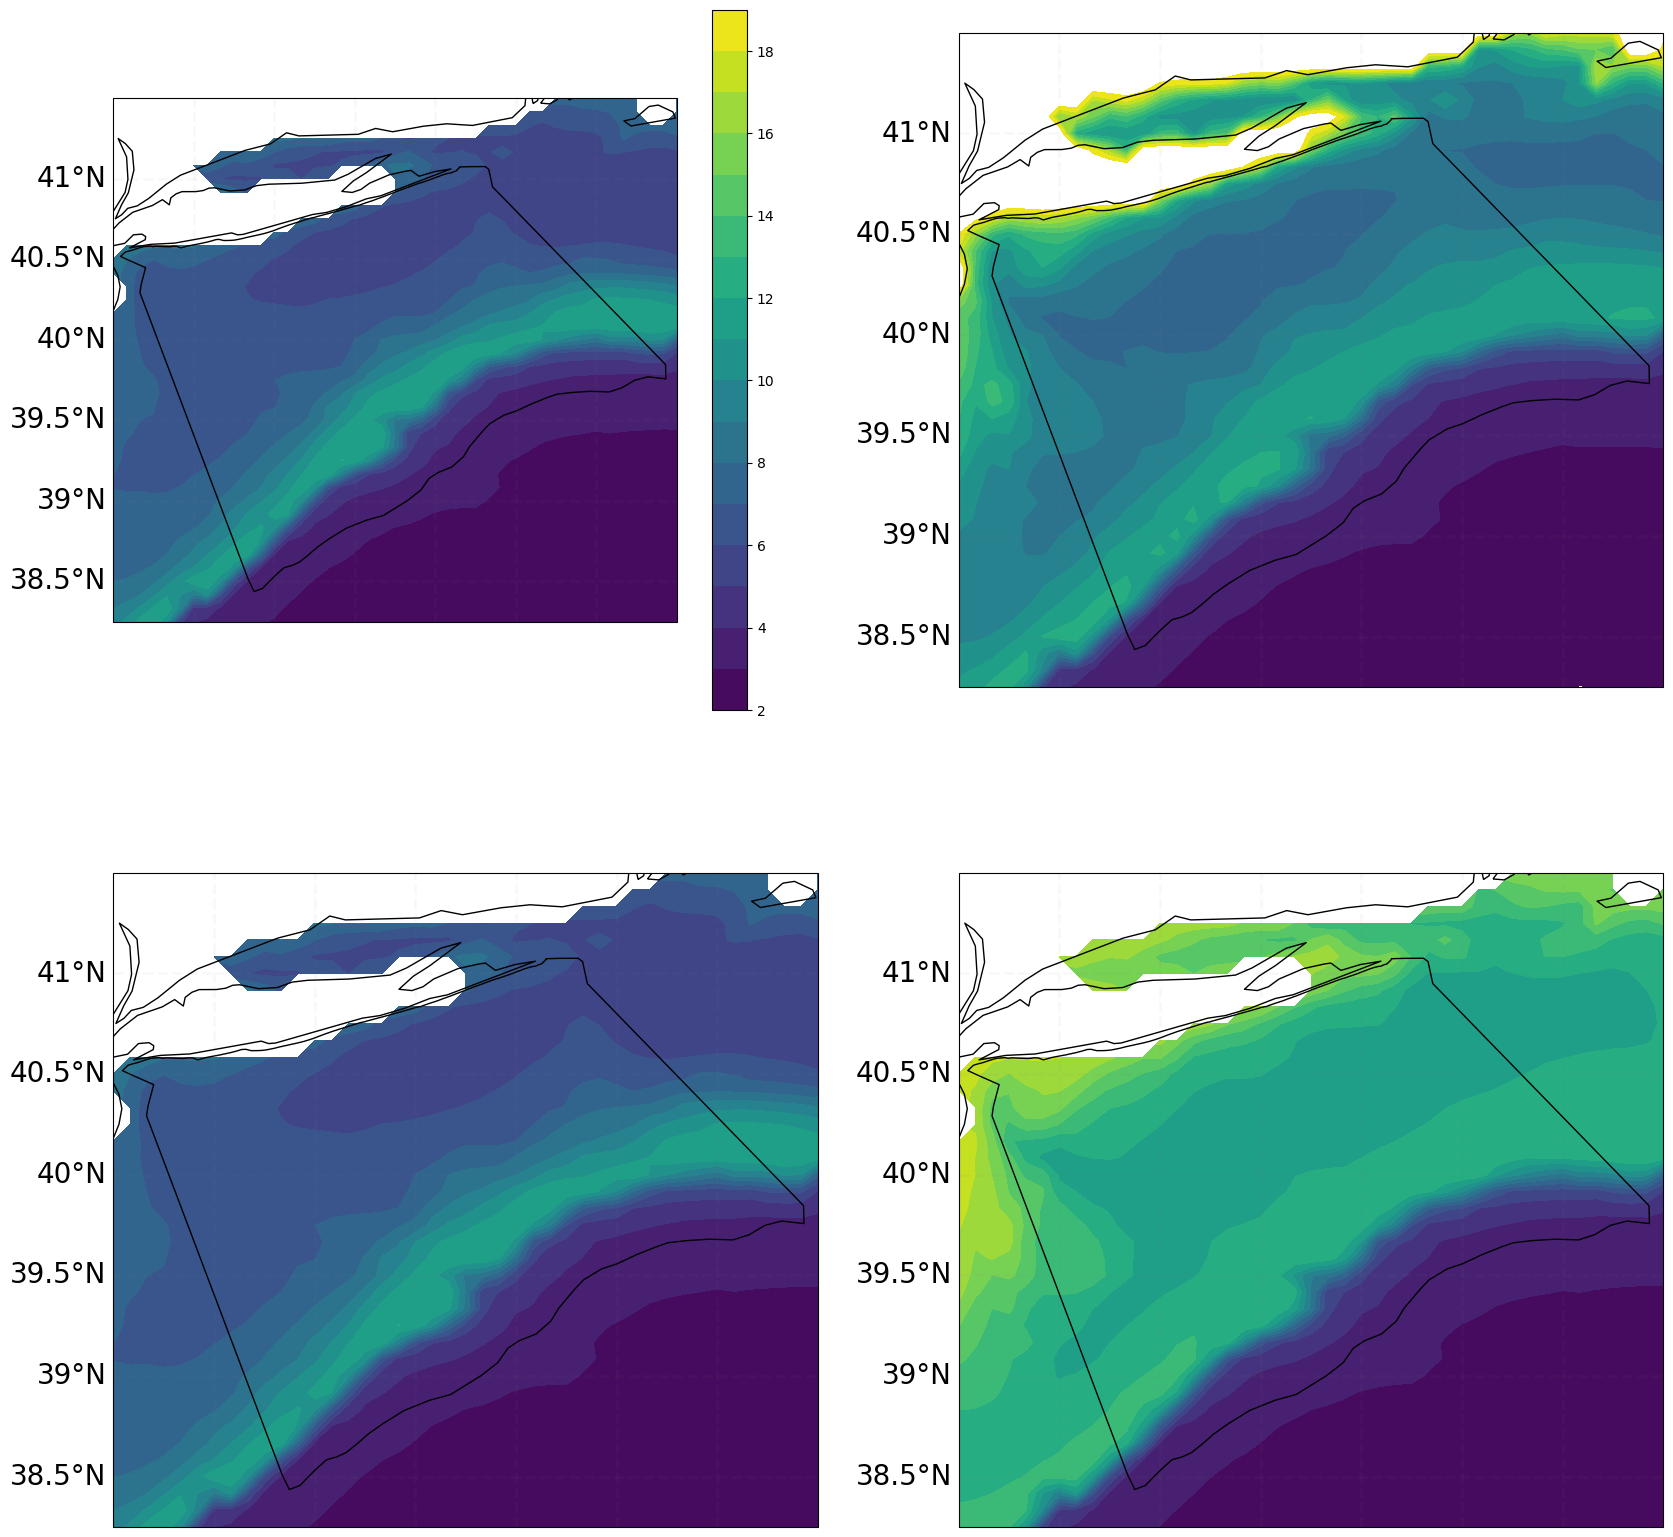

In [53]:
%matplotlib inline
fig,ax = plt.subplots(ncols = 2, nrows = 2, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax[0,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.xlabels_bottom = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 20, 'color': 'k'}
ax[0,0].set_extent(extent)
ax[0,0].coastlines(resolution='50m')
CS = ax[0,0].contourf(glorysBT.longitude,glorysBT.latitude,bott_subset_seas[2,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0,0].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
    
gl = ax[0,1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.xlabels_bottom = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 20, 'color': 'k'}
ax[0,1].set_extent(extent)
ax[0,1].coastlines(resolution='50m')
CS = ax[0,1].contourf(glorysBT.longitude,glorysBT.latitude,bott_subset_seas[1,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0,1].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
    
gl = ax[1,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.xlabels_bottom = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 20, 'color': 'k'}
ax[1,0].set_extent(extent)
ax[1,0].coastlines(resolution='50m')
CS = ax[1,0].contourf(glorysBT.longitude,glorysBT.latitude,bott_subset_seas[2,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1,0].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)

gl = ax[1,1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.05, linestyle='--')
gl.xlabels_top = False
gl.xlabels_bottom = False
gl.ylabels_right = False
gl.ylabel_style = {'size': 20, 'color': 'k'}
ax[1,1].set_extent(extent)
ax[1,1].coastlines(resolution='50m')
CS = ax[1,1].contourf(glorys.longitude,glorys.latitude,bott_subset_seas[3,:,:],levels = np.arange(2,20,1),transform=ccrs.PlateCarree())
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1,1].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)

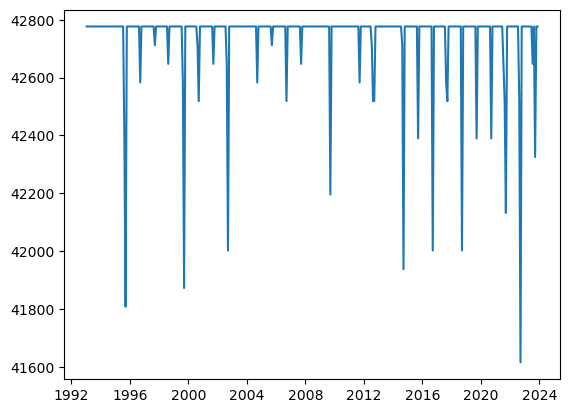

In [54]:
plt.plot(glorysBT.time, Area)

In [55]:
#Total area of NYB at seafloor
Area[0]

42776.96407357517

In [56]:
#Check when Lobster Thermal habitat is more than 1% inhospitable
np.where(((Area[0]-Area)/Area[0])*100>1)

(array([ 32,  80, 116, 200, 260, 284, 308, 344, 356, 368]),)

Text(0.5, 1.0, 'Lobster Thermal Habitat')

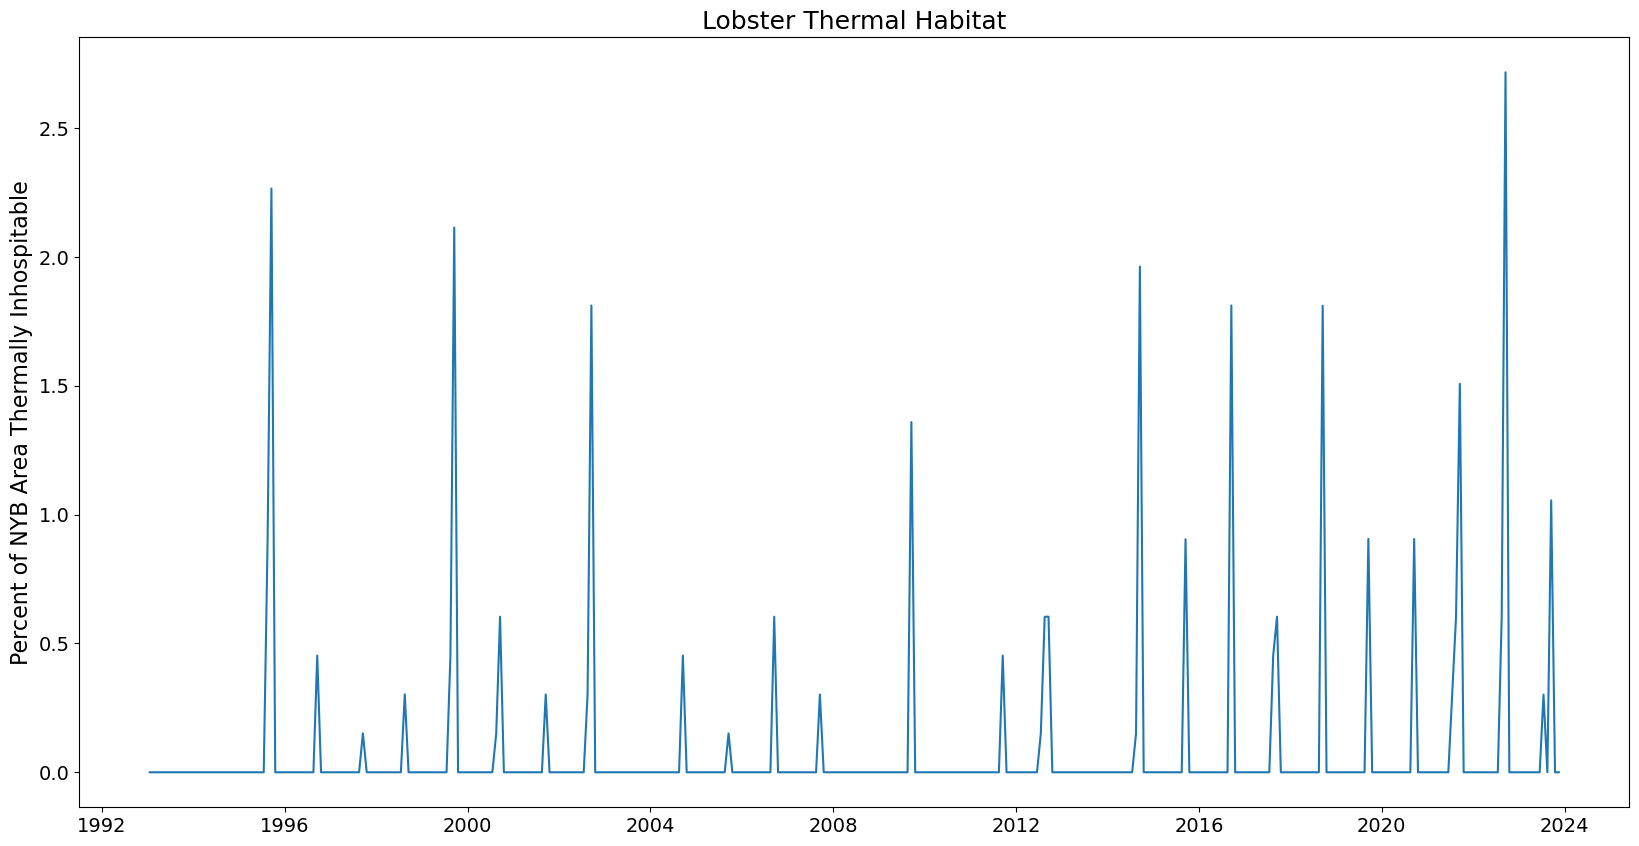

In [58]:
#Time series of %Area inhospitable to lobsters
fig, ax = plt.subplots(figsize = [20,10])
plt.plot(glorys.time, ((Area[0]-Area)/Area[0])*100)
ax.tick_params(labelsize = 14)
ax.set_ylabel('Percent of NYB Area Thermally Inhospitable', fontsize = 16)
ax.set_title('Lobster Thermal Habitat', fontsize = 18)

In [59]:
# Create one pandas data frame and save to final timeseries folder
d = {'Percent_Inhospitable': ((Area[0]-Area)/Area[0])*100}
LTH = pn.DataFrame(data = d, index = glorys.time.values)
LTH.to_csv('/Users/nyelab/Desktop/NYB Indicators/NYB_Indicators_Calculations/Final_Timeseries_Figures/Timeseries_Files_2023/Lobster_Thermal_Hab_Jan_3_2023.csv')

In [61]:
LTH_yearly = LTH.groupby(LTH.index.year).mean()

In [62]:
LTH[LTH.Percent_Inhospitable >2
   ]

,Percent_Inhospitable
1995-09-16,2.265686
1999-09-16,2.114553
2022-09-16,2.717016


In [63]:
# Here we are saving the final timeseries file to be used for the figure for the indicator report
LTH_yearly.to_csv('/Users/nyelab/Desktop/NYB Indicators//NYB_Indicators_Calculations/Final_Timeseries_Figures/Timeseries_Files_2023/Lobster_Thermal_Hab_Jan_3_2023.csv')

/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecated. Please use .bottom_labels to toggle visibility instead.
  warnings.warn('The .xlabels_bottom attribute is deprecated. Please '


Text(0.5, 1.0, 'September 2018')

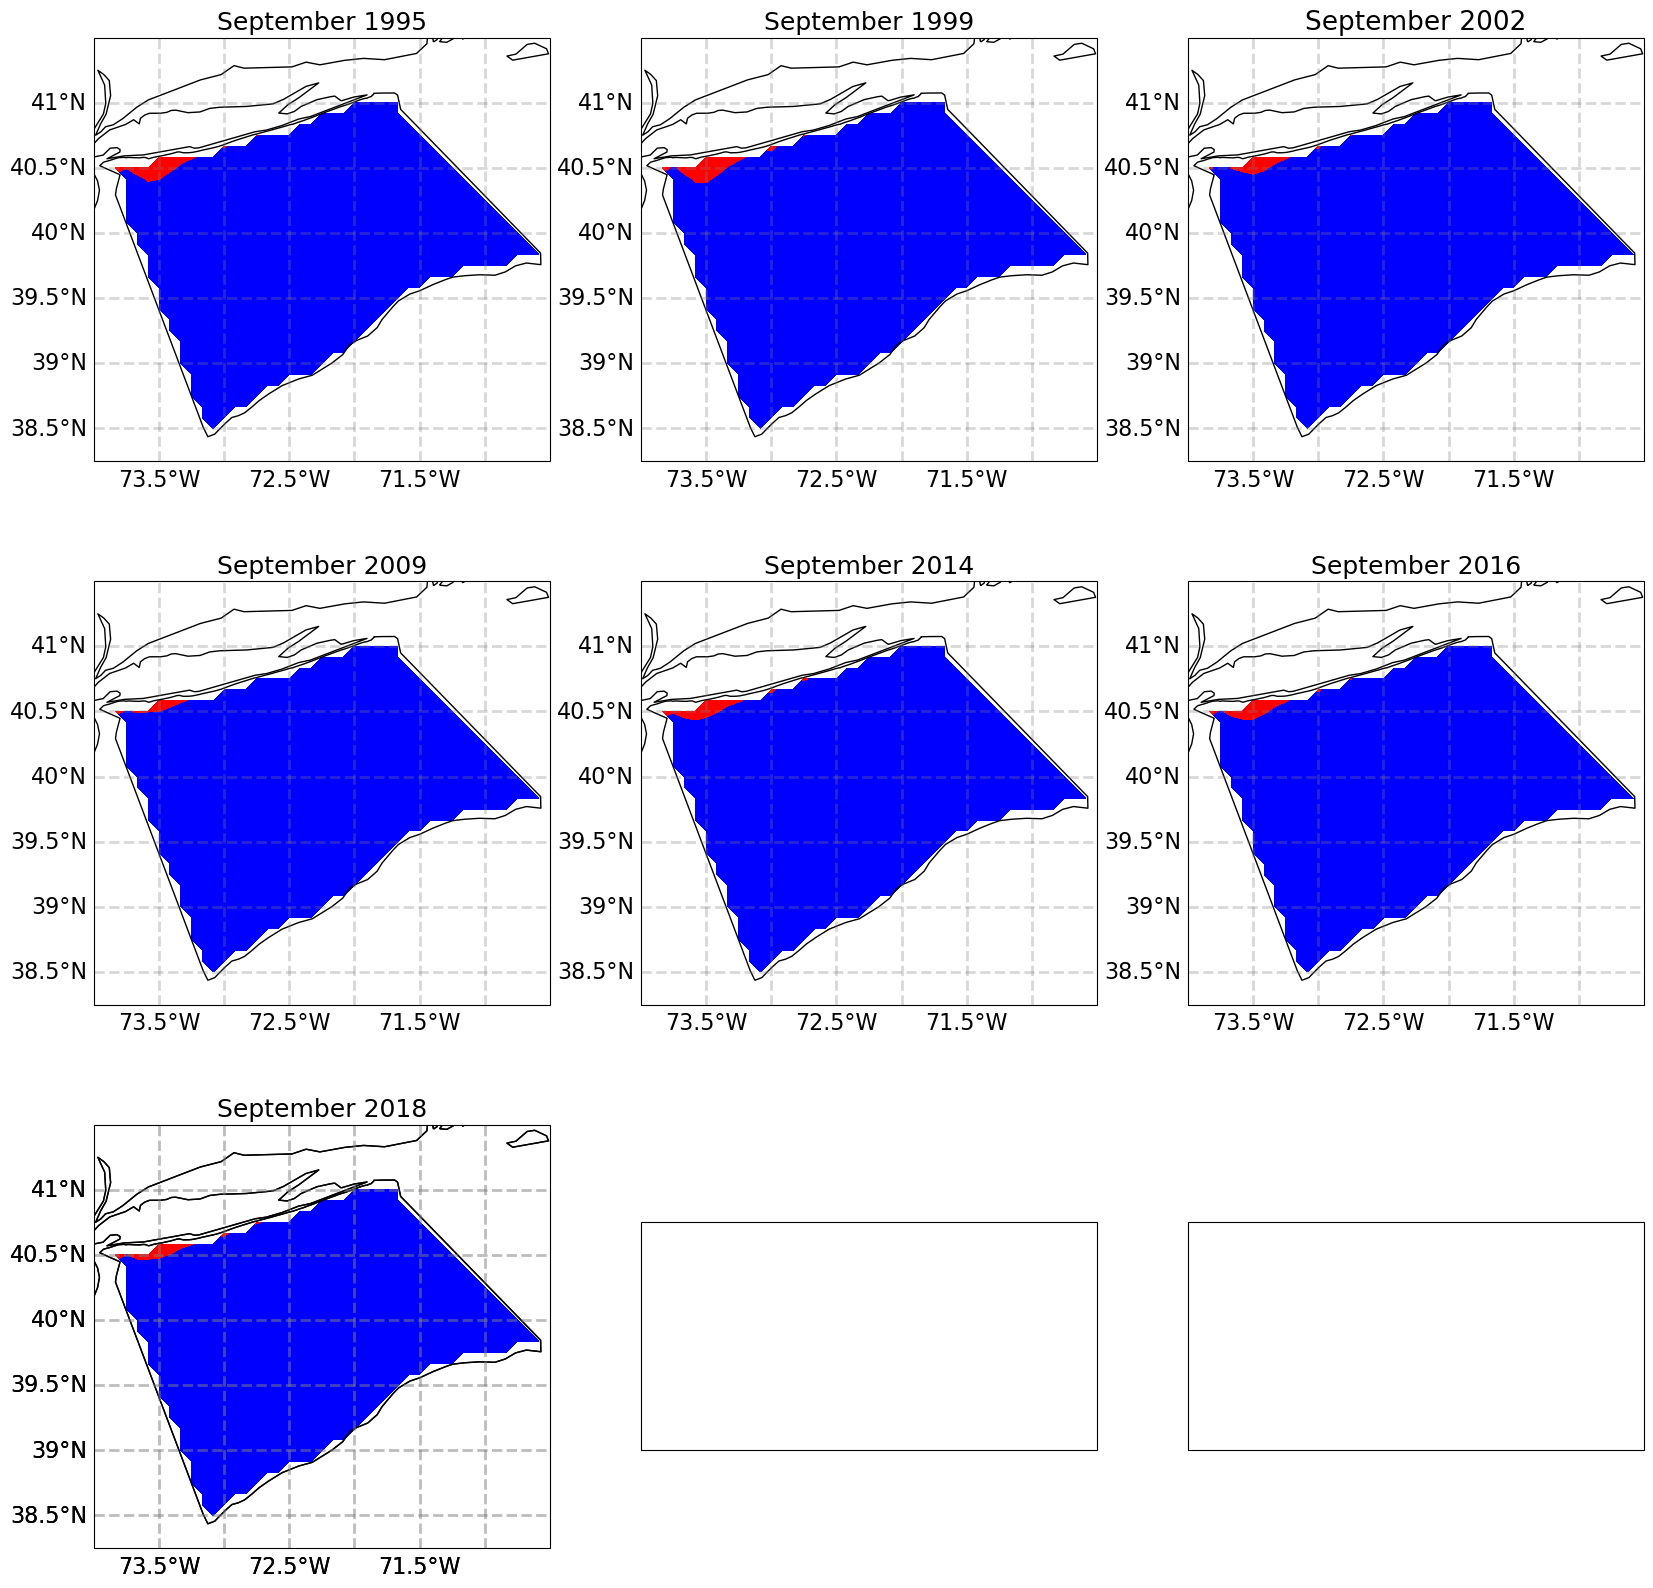

In [64]:
#Plot the months where inhospitable lobster thermal habitat is > 1%
fig,ax = plt.subplots(ncols = 3, nrows = 3, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax[0,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[0,0].set_extent(extent)
ax[0,0].coastlines(resolution='50m')
CS = ax[0,0].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[32,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0,0].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[0,0].set_title(pn.to_datetime(glorys.time[32].values).strftime("%B %Y"), fontsize = 18)
    
gl = ax[0,1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[0,1].set_extent(extent)
ax[0,1].coastlines(resolution='50m')
CS = ax[0,1].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[80,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0,1].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[0,1].set_title(pn.to_datetime(glorys.time[80].values).strftime("%B %Y"), fontsize = 18)
    
gl = ax[0,2].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[0,2].set_extent(extent)
ax[0,2].coastlines(resolution='50m')
CS = ax[0,2].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[116,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[0,2].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[0,2].set_title(pn.to_datetime(glorys.time[116].values).strftime("%B %Y"), fontsize = 19)

gl = ax[1,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[1,0].set_extent(extent)
ax[1,0].coastlines(resolution='50m')
CS = ax[1,0].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[200,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1,0].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[1,0].set_title(pn.to_datetime(glorys.time[200].values).strftime("%B %Y"), fontsize = 18)
    
gl = ax[1,1].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[1,1].set_extent(extent)
ax[1,1].coastlines(resolution='50m')
CS = ax[1,1].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[260,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1,1].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[1,1].set_title(pn.to_datetime(glorys.time[260].values).strftime("%B %Y"), fontsize = 18)

gl = ax[1,2].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[1,2].set_extent(extent)
ax[1,2].coastlines(resolution='50m')
CS = ax[1,2].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[284,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[1,2].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[1,2].set_title(pn.to_datetime(glorys.time[284].values).strftime("%B %Y"), fontsize = 18)
    
gl = ax[2,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[2,0].set_extent(extent)
ax[2,0].coastlines(resolution='50m')
CS = ax[2,0].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[308,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[2,0].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[2,0].set_title(pn.to_datetime(glorys.time[308].values).strftime("%B %Y"), fontsize = 18)


gl = ax[2,0].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax[2,0].set_extent(extent)
ax[2,0].coastlines(resolution='50m')
CS = ax[2,0].contourf(glorysBT.longitude,glorysBT.latitude,glorys_nyb_bot_t[308,:,:],levels = [20,20.0001],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'bwr')
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
ax[2,0].add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax[2,0].set_title(pn.to_datetime(glorys.time[308].values).strftime("%B %Y"), fontsize = 18)

In [65]:
pn.to_datetime(glorys.time[308].values).strftime("%Y-%m")


'2018-09'

## COLD POOL SECTION we will consider the cold pool to be the water mass 10C or colder and 34psu or fresher

In [33]:
# Returns depth of the 10degree isotherm at each grid point and each month
def depth10(temp,ntime,ndepth,nlat,nlon):
    d10 = np.empty([ntime,nlat,nlon])
    d10[:,:,:] = np.nan
    for i in range(25,70):
        for j in range(70,115):
            point = temp[:,:,i,j]
            for k in range(371):
                if np.any(point[k,:]>0):
                    x = 10
                    xp = point[k,:]
                    xp = np.flip(xp[np.where(xp>0)])
                    y = glorys.depth
                    y = np.flip(y[np.where(xp>0)])
                    d10[k,i,j] = np.interp(x,xp,y)
        print(i)
    return d10

In [34]:
# returns a matrix of where the temperature of the water is less than 10 degrees at each grid point and each month and depth
def less_than_10(temp,ntime,ndepth,nlat,nlon):
    LT10 = np.empty([ntime,ndepth,nlat,nlon])
    LT10[:,:,:,:] = np.nan
    for i in range(25,70):
        for j in range(70,115):
            point = temp[:,:,i,j]
            for k in range(371):
                if np.any(point[k,:]>0):
                    index_T = np.where(point[k,:]<=10)
                    LT10[k,index_T,i,j] = 1
        print(i)
    return LT10

In [35]:
# returns a metrix of where the salinity of the water is less than 34 PSU at each gridpoint and each month and depth
def less_than_34(salt,ntime,ndepth,nlat,nlon):
    LT34 = np.empty([ntime,ndepth,nlat,nlon])
    LT34[:,:,:,:] = np.nan
    for i in range(25,70):
        for j in range(70,115):
            point = salt[:,:,i,j]
            for k in range(371):
                if np.any(point[k,:]>0):
                    index_T = np.where(point[k,:]<=34)
                    LT34[k,index_T,i,j] = 1
        print(i)
    return LT34

In [36]:
# Returns the depth of the 34 PSU salinity contour at each gridpoint and each month
def depth34(salinity,ntime,ndepth,nlat,nlon):
    d34 = np.empty([ntime,nlat,nlon])
    d34[:,:,:] = np.nan
    for i in range(25,70):
        for j in range(70,115):
            point = salinity[:,:,i,j]
            for k in range(371):
                p = point[k,:]
                no = np.where(np.isnan(p)==False)
                p = p[no]
                if np.any(p>0):
                    if p.max()<34:
                        d34[k,i,j] = 0.494025
                    if p.min()<34 and p.max()>34:
                        x = 34
                        xp = p
                        y = glorys.depth[no]
                        d34[k,i,j] = np.interp(x,xp,y)
        print(i)
    return d34

In [70]:
glorys

<xarray.Dataset>
Dimensions:    (depth: 41, latitude: 73, time: 371, longitude: 241)
Coordinates:
  * depth      (depth) float32 0.494 1.541 2.646 ... 1.942e+03 2.225e+03
  * latitude   (latitude) float32 36.0 36.08 36.17 36.25 ... 41.83 41.92 42.0
  * time       (time) datetime64[ns] 1993-01-16T12:00:00 ... 2023-11-16
  * longitude  (longitude) float32 -80.0 -79.92 -79.83 ... -60.17 -60.08 -60.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 nan nan ... nan nan
Attributes:
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    units:          degrees_C
    unit_long:      Degrees Celsius
    cell_methods:   area: mean
    _ChunkSizes:    [  1   7 341 720]

In [37]:
# Find depth of the 10 degree isotherm
d10 = depth10(glorys_nyb_theta,371,41,73,241)

25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


In [38]:
# Find depth of the 34 PSU isohaline
d34 = depth34(glorys_nyb_salt,371,41,73,241)

25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


In [39]:
# Find everywhere the temp is equal to or less than 10 degrees
LT10 = less_than_10(glorys_nyb_theta,371,41,73,241)

25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


In [40]:
# Find everywhere the salinity is equal to or less than 34 PSU
LT34 = less_than_34(glorys_nyb_salt,371,41,73,241)

25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69


In [75]:
glorys.latitude[45]


<xarray.DataArray 'latitude' ()>
array(39.75, dtype=float32)
Coordinates:
    latitude  float32 39.75
Attributes:
    valid_min:            36.0
    valid_max:            42.0
    step:                 0.08333588
    units:                degrees_north
    unit_long:            Degrees North
    long_name:            Latitude
    standard_name:        latitude
    axis:                 Y
    _ChunkSizes:          2041
    _CoordinateAxisType:  Lat

In [76]:
glorys.time[-6]

<xarray.DataArray 'time' ()>
array('2023-06-16T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 2023-06-16
Attributes:
    axis:                 T
    long_name:            Time (hours since 1950-01-01)
    standard_name:        time
    _CoordinateAxisType:  Time
    valid_min:            377316.0
    valid_max:            481764.0

/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/Users/nyelab/miniconda3/envs/my_env/lib/python3.8/site-packages/cartopy/mpl/gridliner.py:463: UserWarning: The .xlabels_bottom attribute is deprecated. Please use .bottom_labels to toggle visibility instead.
  warnings.warn('The .xlabels_bottom attribute is deprecated. Please '


Text(0.5, 1.0, 'June 2023')

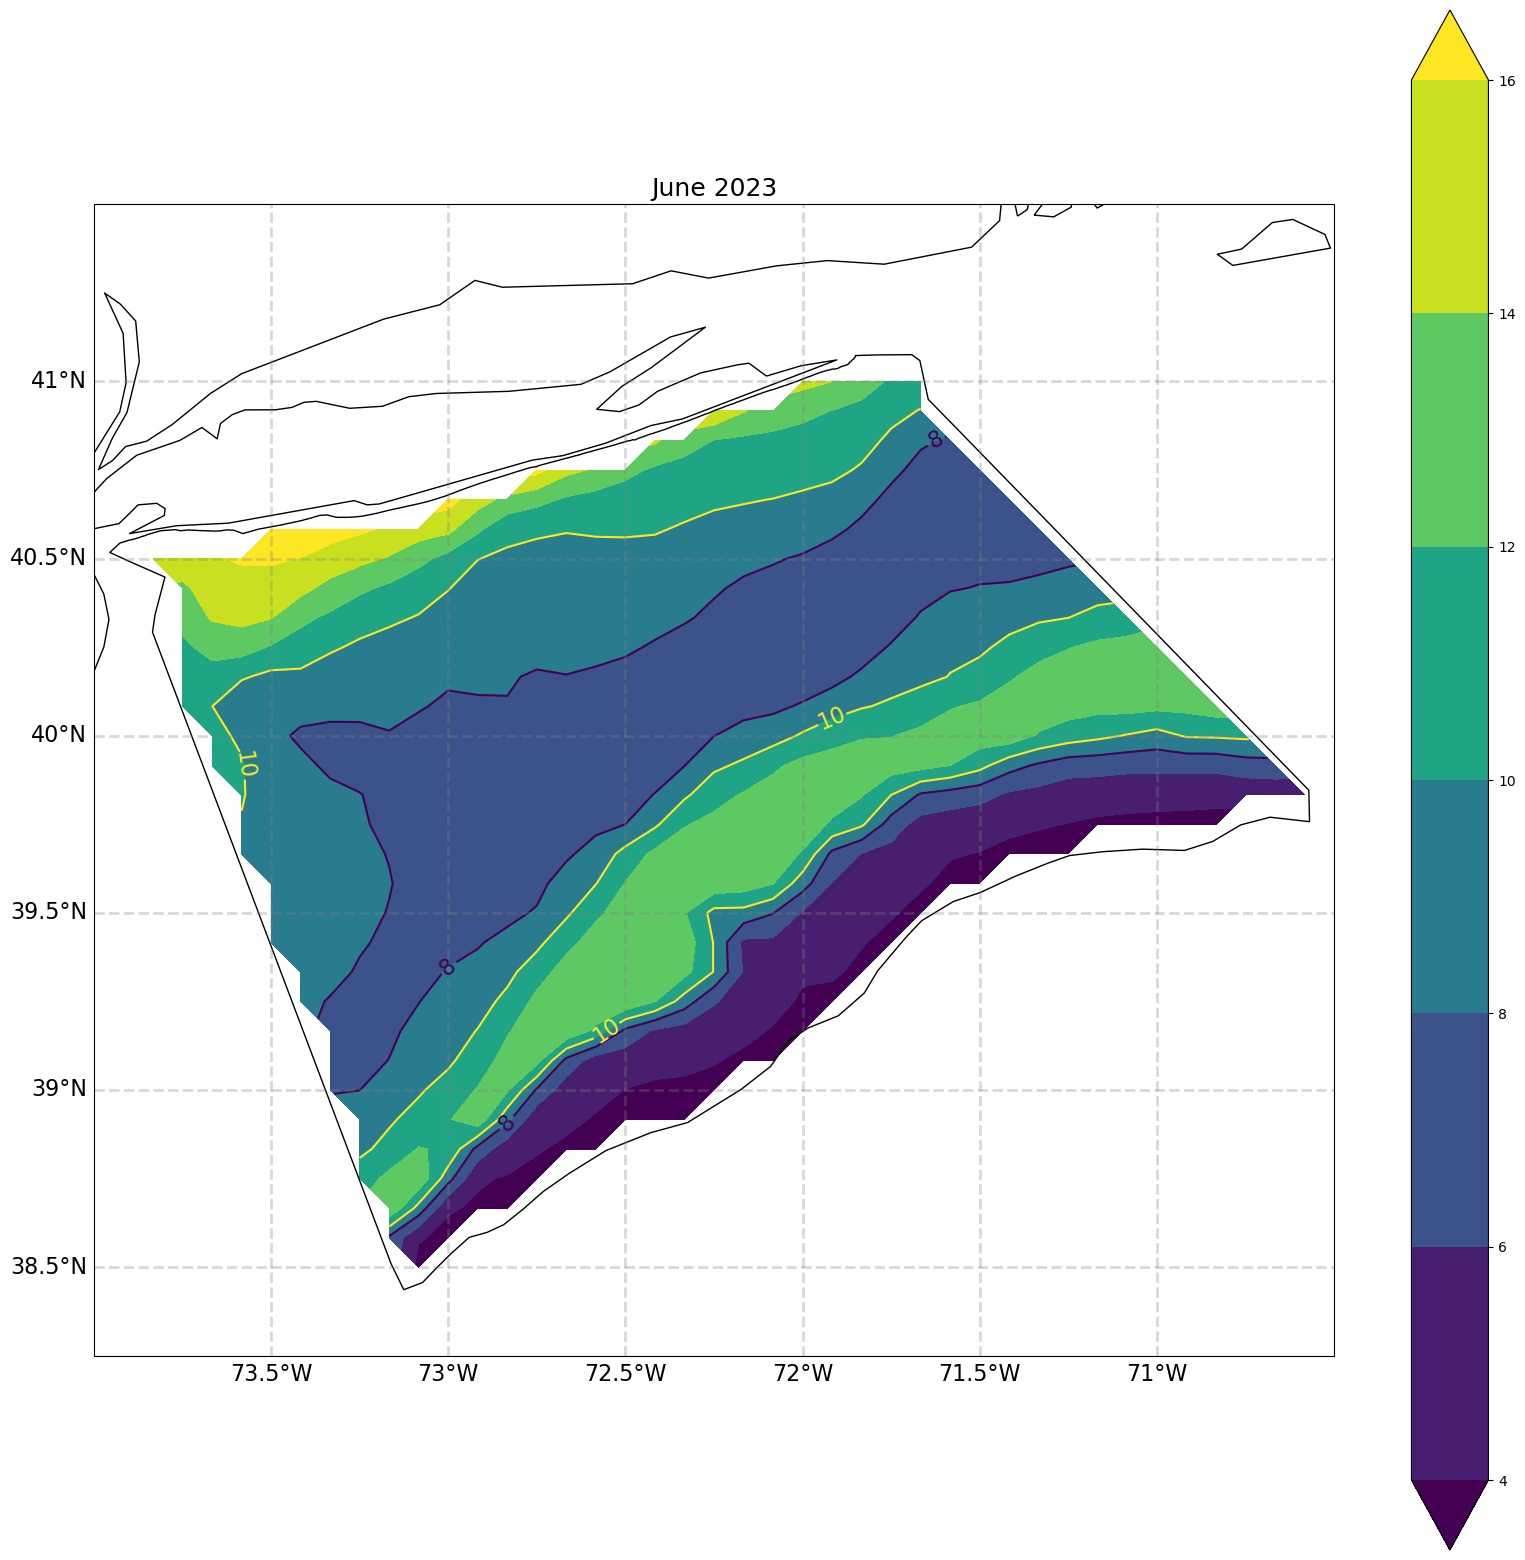

In [41]:
#Plot the months where inhospitable lobster thermal habitat is > 1%
fig,ax = plt.subplots(ncols = 1, nrows = 1, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax.set_extent(extent)
ax.coastlines(resolution='50m')
CS = ax.contourf(glorys.longitude,glorys.latitude,glorys_nyb_bot_t[-6,:,:],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'viridis')
C = ax.contour(glorys.longitude,glorys.latitude,glorys_nyb_bot_t[-6,:,:], levels = [8,10],extend = 'both',transform=ccrs.PlateCarree())
#ax[0].contour(glorys.longitude,glorys.latitude,glorys_nyb_salt[-9,:,:], levels = [34],extend = 'both',transform=ccrs.PlateCarree())

#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
ax.clabel(C, fontsize=16, inline=1, fmt='%1.0f')
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
plt.colorbar(CS)
ax.add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax.set_title(pn.to_datetime(glorys.time[-6].values).strftime("%B %Y"), fontsize = 18)

#ax[1].contourf(glorys.longitude, glorys.depth,glorys_nyb_theta[-8,:, 45,:])
#ax[1].set_ylim([250,0])
#ax[1].set_xlim([-74,-70.8])



/var/folders/ys/jb4xnd9x6vb6xqb52tk47scr0000gp/T/ipykernel_68748/3573916160.py:5: UserWarning: The following kwargs were not used by contour: 'color'
  c2 = ax.contour(glorys.longitude, glorys.depth,glorys_nyb_salt[-6,:, 45,:], levels = np.arange(32,36,0.5), linestyles = 'dashed', color = 'k')


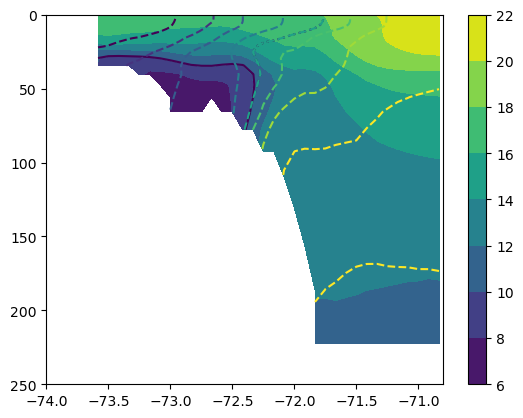

In [78]:
fig, ax = plt.subplots()
c = ax.contourf(glorys.longitude, glorys.depth,glorys_nyb_theta[-6,:, 45,:])
ax.contour(glorys.longitude, glorys.depth,glorys_nyb_theta[-6,:, 45,:], levels = [10.1])
ax.contour(glorys.longitude, glorys.depth,glorys_nyb_salt[-6,:, 45,:], levels = [34], linestyles = 'dotted')
c2 = ax.contour(glorys.longitude, glorys.depth,glorys_nyb_salt[-6,:, 45,:], levels = np.arange(32,36,0.5), linestyles = 'dashed', color = 'k')
plt.clabel(c2)
ax.set_ylim([250,0])
ax.set_xlim([-74,-70.8])
plt.colorbar(c)

In [42]:
# puts a 1 in a matrix where both temp <= 10 and salinity <= 34.  Everywhere else is a zero.
LT_34_10 = LT34 * LT10

In [80]:
np.shape(LT_34_10)

(371, 41, 73, 241)

In [43]:
z = np.zeros([371,73,241])
for i in range(371):
    for j in range(73):
        for k in range(241):
            profile = LT_34_10[i,:,j,k]*glorys.depth
            if np.nanmin(profile) >0 and np.nanmax(profile)>0:
                z[i,j,k] = np.nanmax(profile) - np.nanmin(profile)
    print(str((i/371) * 100) + '% done')

/var/folders/ys/jb4xnd9x6vb6xqb52tk47scr0000gp/T/ipykernel_6147/2392300057.py:6: RuntimeWarning: All-NaN axis encountered
  if np.nanmin(profile) >0 and np.nanmax(profile)>0:


0.0% done
0.2695417789757413% done
0.5390835579514826% done
0.8086253369272237% done
1.078167115902965% done
1.3477088948787064% done
1.6172506738544474% done
1.8867924528301887% done
2.15633423180593% done
2.4258760107816713% done
2.6954177897574128% done
2.964959568733154% done
3.234501347708895% done
3.5040431266846364% done
3.7735849056603774% done
4.0431266846361185% done
4.31266846361186% done
4.5822102425876015% done
4.8517520215633425% done
5.121293800539084% done
5.3908355795148255% done
5.660377358490567% done
5.929919137466308% done
6.199460916442049% done
6.46900269541779% done
6.738544474393531% done
7.008086253369273% done
7.277628032345014% done
7.547169811320755% done
7.816711590296496% done
8.086253369272237% done
8.355795148247978% done
8.62533692722372% done
8.89487870619946% done
9.164420485175203% done
9.433962264150944% done
9.703504043126685% done
9.973045822102426% done
10.242587601078167% done
10.512129380053908% done
10.781671159029651% done
11.05121293800539%

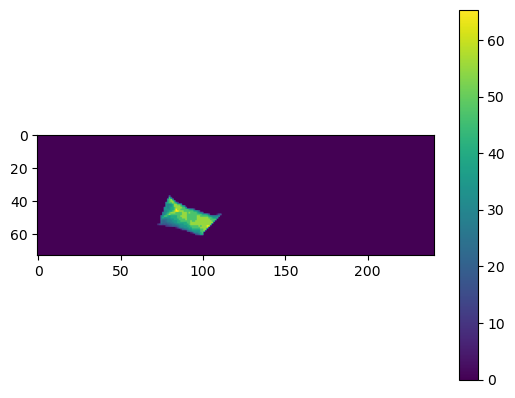

In [93]:
plt.imshow(z[338,:,:])
plt.colorbar()

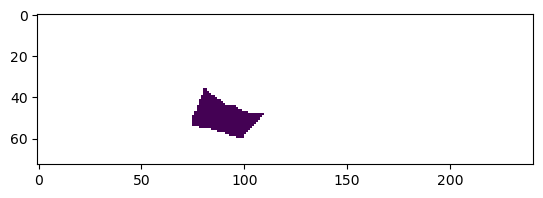

In [83]:
plt.imshow(LT10[338,3,:,:])

In [84]:
volume_area = (area * 1000 * 1000) * z


In [85]:
np.shape(volume_area)

(371, 73, 241)

In [86]:
volume_area[volume_area == 0] = np.nan

In [87]:
glorys.latitude[53]

<xarray.DataArray 'latitude' ()>
array(40.416668, dtype=float32)
Coordinates:
    latitude  float32 40.42
Attributes:
    valid_min:            36.0
    valid_max:            42.0
    step:                 0.08333588
    units:                degrees_north
    unit_long:            Degrees North
    long_name:            Latitude
    standard_name:        latitude
    axis:                 Y
    _ChunkSizes:          2041
    _CoordinateAxisType:  Lat

Text(0.5, 1.0, 'May 2007')

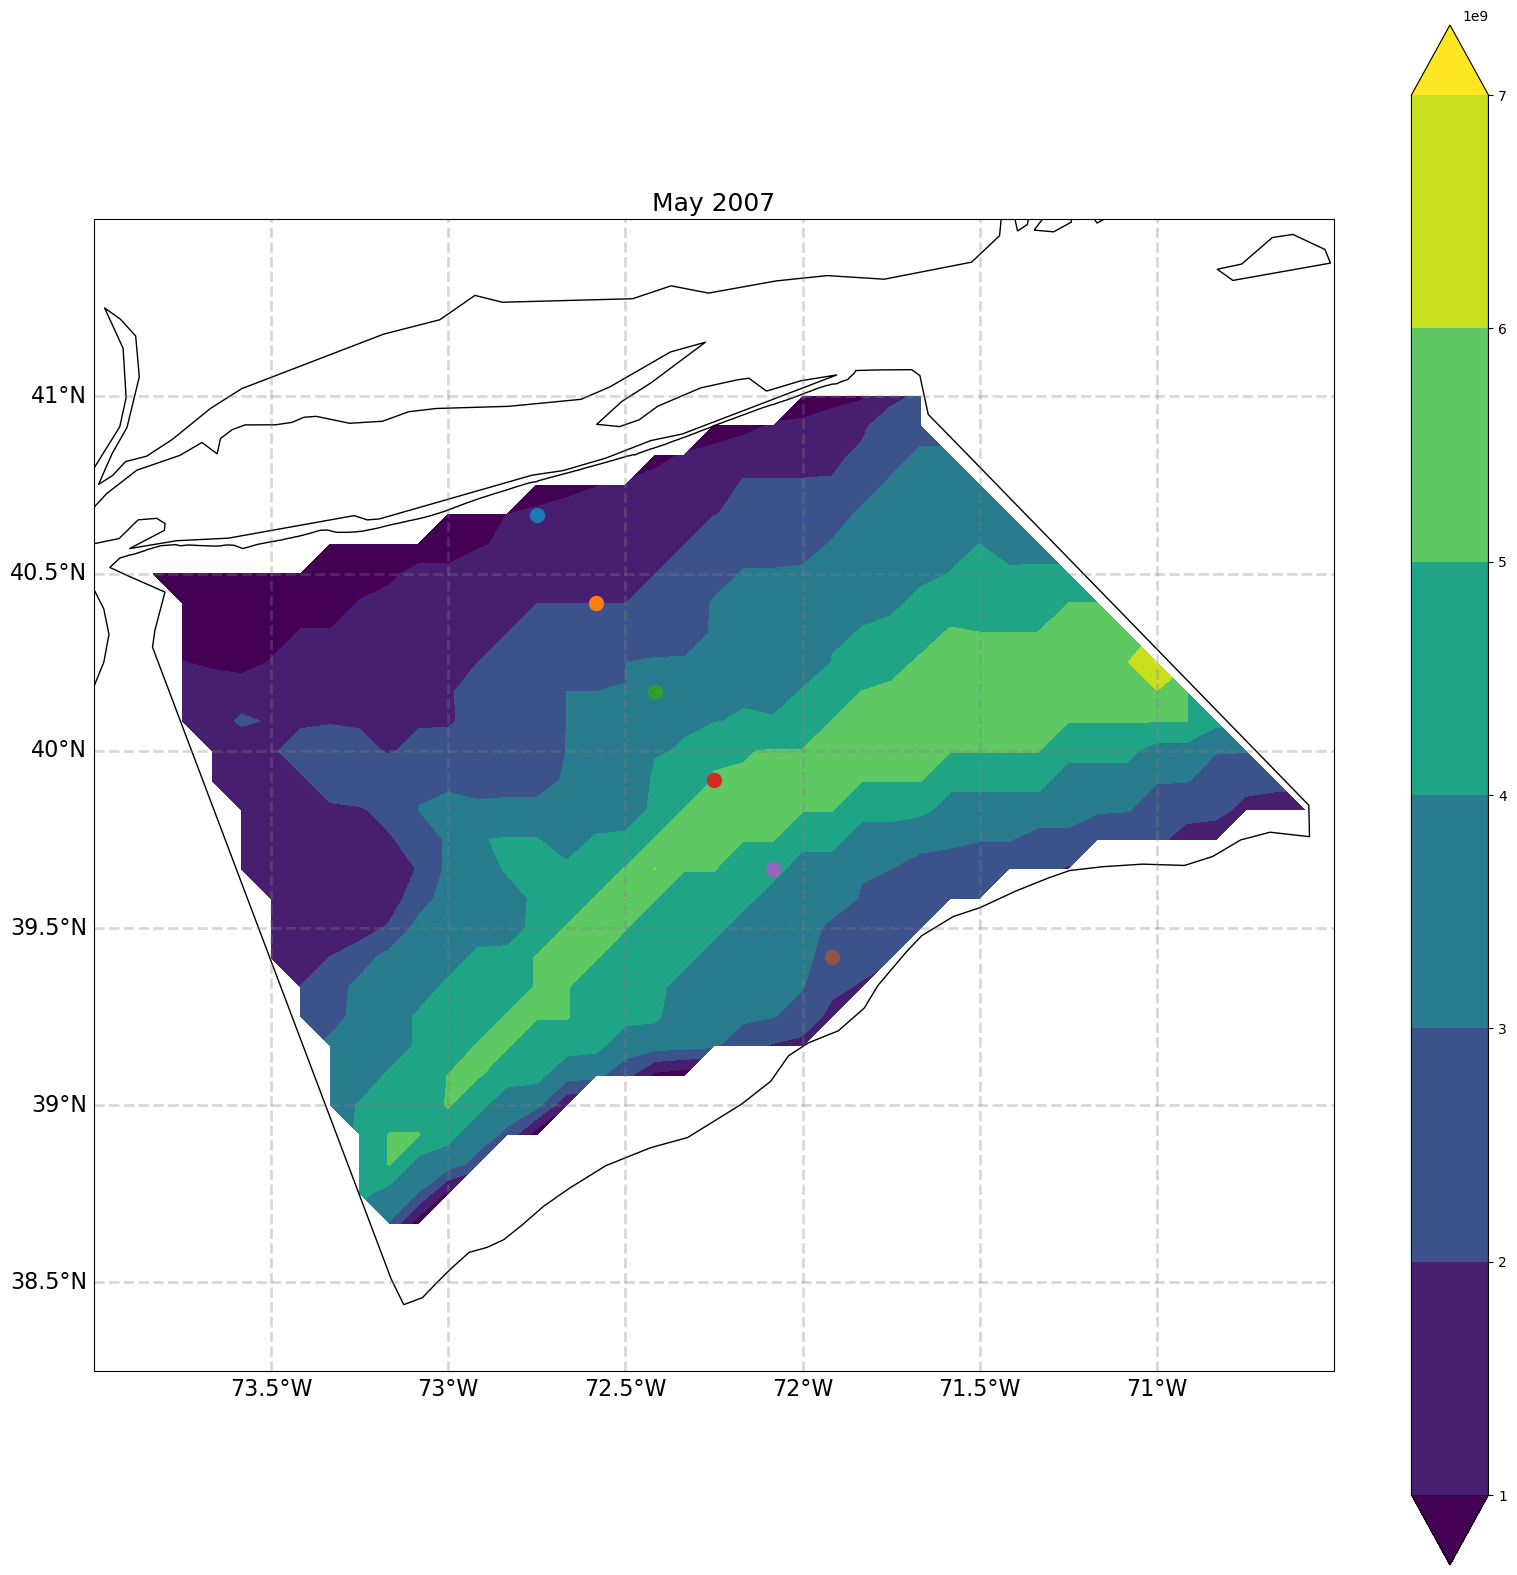

In [88]:
#Plot the months where inhospitable lobster thermal habitat is > 1%
yr_num = 14
t = 4+(12*yr_num)

fig,ax = plt.subplots(ncols = 1, nrows = 1, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax.set_extent(extent)
ax.coastlines(resolution='50m')
CS = ax.contourf(glorys.longitude,glorys.latitude,volume_area[t,:,:],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'viridis')
ax.contour(glorys.longitude,glorys.latitude,volume_area[t,:,:], levels = [10],extend = 'both',transform=ccrs.PlateCarree())
#ax[0].contour(glorys.longitude,glorys.latitude,glorys_nyb_salt[-9,:,:], levels = [34],extend = 'both',transform=ccrs.PlateCarree())
ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
ax.scatter(glorys.longitude[89], glorys.latitude[53], s = 100)
ax.scatter(glorys.longitude[91], glorys.latitude[50], s = 100)
ax.scatter(glorys.longitude[93], glorys.latitude[47], s = 100)
ax.scatter(glorys.longitude[95], glorys.latitude[44], s = 100)
ax.scatter(glorys.longitude[97], glorys.latitude[41], s = 100)
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
plt.colorbar(CS)
ax.add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax.set_title(pn.to_datetime(glorys.time[t].values).strftime("%B %Y"), fontsize = 18)


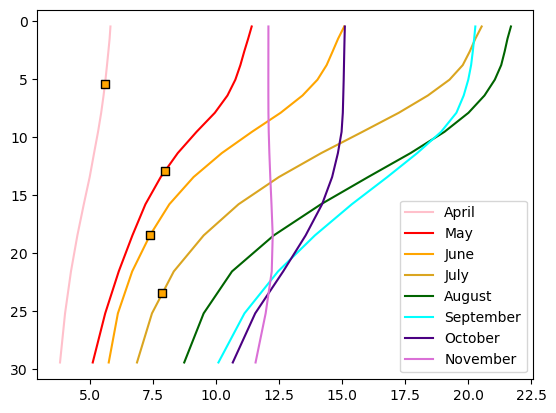

In [44]:
colors = ['pink','red','orange','goldenrod','darkgreen','cyan','indigo','orchid']
labels = ['April', 'May','June','July','August','September','October','November']
for i in range(3,11):
    f = sio.interp1d(glorys.depth, glorys.thetao[i,:,56,87])
#ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
    plt.plot(glorys.thetao[i,:,56,87], glorys.depth,zorder = 0, color = colors[i-3], label = labels[i-3])
    if z[i,56,87] > 0:
        plt.scatter(f(glorys.depth[len(glorys.thetao[i,:,56,87][np.isnan(glorys.thetao[i,:,56,87])==False])] - z[i,56,87]), glorys.depth[len(glorys.thetao[i,:,56,87][np.isnan(glorys.thetao[i,:,56,87])==False])] - z[i,56,87], s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
plt.gca().invert_yaxis()
plt.legend()

In [90]:
glorys.thetao[360,:,56,87]

<xarray.DataArray 'thetao' (depth: 41)>
array([6.680312 , 6.6808515, 6.679848 , 6.677863 , 6.6791406, 6.68645  ,
       6.703145 , 6.7366285, 6.800235 , 6.8881116, 7.0352626, 7.270306 ,
       7.534554 , 7.6722155, 7.8806753,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan,       nan,
             nan,       nan,       nan,       nan,       nan],
      dtype=float32)
Coordinates:
  * depth      (depth) float32 0.494 1.541 2.646 ... 1.942e+03 2.225e+03
    latitude   float32 40.67
    time       datetime64[ns] 2023-01-16T12:00:00
    longitude  float32 -72.75
Attributes:
    long_name:      Temperature
    standard_name:  sea_water_potential_temperature
    units:          degrees_C
    unit_long:      Degrees Celsius
    cell_methods:   area: mean
    _ChunkSizes:    [  1   7 341 720]

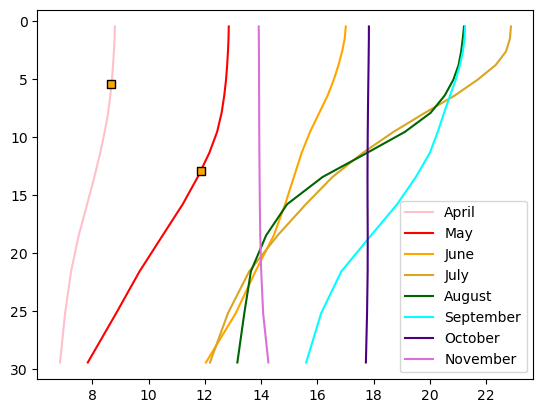

In [91]:
colors = ['pink','red','orange','goldenrod','darkgreen','cyan','indigo','orchid']
labels = ['April', 'May','June','July','August','September','October','November']
for i in range(3,11):
    f = sio.interp1d(glorys.depth, glorys.thetao[360+i,:,56,87])
#ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
    plt.plot(glorys.thetao[360+i,:,56,87], glorys.depth,zorder = 0, color = colors[i-3], label = labels[i-3])
    if z[360+i,56,87] > 0:
        plt.scatter(f(glorys.depth[len(glorys.thetao[i,:,56,87][np.isnan(glorys.thetao[i,:,56,87])==False])] - z[i,56,87]), glorys.depth[len(glorys.thetao[i,:,56,87][np.isnan(glorys.thetao[i,:,56,87])==False])] - z[i,56,87], s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
plt.gca().invert_yaxis()
plt.legend()

In [92]:
colors = ['pink','red','orange','goldenrod','darkgreen','cyan','indigo','orchid']
labels = ['April', 'May','June','July','August','September','October','November']
for i in range(3,11):
    f = sio.interp1d(glorys.depth, glorys.so[i,:,56,87])
#ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
    plt.plot(glorys.so[i,:,56,87], glorys.depth,zorder = 0, color = colors[i-3], label = labels[i-3])
    if z[i,56,87] > 0:
        plt.scatter(f(glorys.depth[len(glorys.so[i,:,56,87][np.isnan(glorys.so[i,:,56,87])==False])] - z[i,56,87]), glorys.depth[len(glorys.so[i,:,56,87][np.isnan(glorys.so[i,:,56,87])==False])] - z[i,56,87], s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
plt.gca().invert_yaxis()
plt.legend()

AttributeError: 'Dataset' object has no attribute 'so'

In [ ]:
fig, ax = plt.subplots(nrows = 7, ncols = 2, figsize = [10,15], sharex = 'col' )

colors = ['pink','red','orange','goldenrod','darkgreen','cyan','indigo','orchid']
labels = ['April', 'May','June','July','August','September','October','November']
years = ['1993', '1994', '1995', '1996', '1997', '1998','1998','1999']

for j in range(7):
    for i in range(3,11):
        f = sio.interp1d(glorys.depth, glorys.thetao[i+(12*j),:,56,87])
#ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
        ax[j,0].plot(glorys.thetao[i+(12*j),:,56,87], glorys.depth,zorder = 0, color = colors[i-3], label = labels[i-3])
        if z[i,56,87] > 0:
            ax[j,0].scatter(f(glorys.depth[len(glorys.thetao[i+(12*j),:,56,87][np.isnan(glorys.thetao[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87]),
                        glorys.depth[len(glorys.thetao[i+(12*j),:,56,87][np.isnan(glorys.thetao[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
    plt.gca().invert_yaxis()
    #ax[j,0].legend()
    ax[j,0].set_title(years[j] + ' Temperature')
    

for j in range(7):
    for i in range(3,11):
        f = sio.interp1d(glorys.depth, glorys.so[i+(12*j),:,56,87])
#ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
        ax[j,1].plot(glorys.so[i+(12*j),:,56,87], glorys.depth,zorder = 0, color = colors[i-3], label = labels[i-3])
        if z[i,56,87] > 0:
            ax[j,1].scatter(f(glorys.depth[len(glorys.so[i+(12*j),:,56,87][np.isnan(glorys.so[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87]),
                        glorys.depth[len(glorys.so[i+(12*j),:,56,87][np.isnan(glorys.so[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
    plt.gca().invert_yaxis()
    #ax[j,0].legend()
    ax[j,1].set_title(years[j] + ' Salinity')

In [ ]:
fig ,ax = plt.subplots(nrows = 4, ncols = 4, figsize = [15,15])

colors = ['pink','red','orange','goldenrod','darkgreen','cyan','indigo','orchid']
labels = ['April', 'May','June','July','August','September','October','November']
years = ['1993', '1994', '1995', '1996', '1997', '1998','1998','1999']

for i in range(3,11):
    if i < 7:
        for j in range(8):
            f = sio.interp1d(glorys.depth, glorys.thetao[i+(12*j),:,56,87])
            ax[0,i-3].plot(glorys.thetao[i+(12*j),:,56,87], glorys.depth,zorder = 0, color = colors[j], label = years[j])
            if z[i,56,87] > 0:
                ax[0,i-3].scatter(f(glorys.depth[len(glorys.thetao[i+(12*j),:,56,87][np.isnan(glorys.thetao[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87]),
                        glorys.depth[len(glorys.thetao[i+(12*j),:,56,87][np.isnan(glorys.thetao[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
        plt.gca().invert_yaxis()
        ax[0,i-3].set_title(labels[i-3] + ' Temperature')
    if i >=7:
        for j in range(8):
            f = sio.interp1d(glorys.depth, glorys.thetao[i+(12*j),:,56,87])
#ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
            ax[2,i-7].plot(glorys.thetao[i+(12*j),:,56,87], glorys.depth,zorder = 0, color = colors[j], label = years[j])
            if z[i,56,87] > 0:
                ax[2,i-7].scatter(f(glorys.depth[len(glorys.thetao[i+(12*j),:,56,87][np.isnan(glorys.thetao[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87]),
                        glorys.depth[len(glorys.thetao[i+(12*j),:,56,87][np.isnan(glorys.thetao[i+(12*j),:,56,87])==False])] - z[i+(12*j),56,87],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
        plt.gca().invert_yaxis()
        ax[2,i-7].set_title(labels[i-3] + ' Temperature')

In [ ]:
fig ,ax = plt.subplots(figsize = [20,10])

Groups = ['93-95', '96-00', '01-05', '06-10','11-15','16-20']
colors = ['pink','red','orange','darkgreen','indigo','orchid']

#ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
#ax.scatter(glorys.longitude[89], glorys.latitude[53], s = 100)
#ax.scatter(glorys.longitude[91], glorys.latitude[50], s = 100)
#ax.scatter(glorys.longitude[93], glorys.latitude[47], s = 100)
#ax.scatter(glorys.longitude[95], glorys.latitude[44], s = 100)
#ax.scatter(glorys.longitude[97], glorys.latitude[41], s = 100)


latind = 56
lonind = 87

#AUGUST
month = 7
#group1
mean1 = np.nanmean(glorys.thetao[[month+(12*0),month+(12*1), month+(12*2)], :,latind,lonind],0)
mean2 = np.nanmean(glorys.thetao[[month+(12*3),month+(12*4), month+(12*5), month+(12*6), month+(12*7)], :,latind,lonind],0)
mean3 = np.nanmean(glorys.thetao[[month+(12*8),month+(12*9), month+(12*10), month+(12*11), month+(12*12)], :,latind,lonind],0)
mean4 = np.nanmean(glorys.thetao[[month+(12*13),month+(12*14), month+(12*15), month+(12*16), month+(12*17)], :,latind,lonind],0)
mean5 = np.nanmean(glorys.thetao[[month+(12*18),month+(12*19), month+(12*20), month+(12*21), month+(12*22)], :,latind,lonind],0)
mean6 = np.nanmean(glorys.thetao[[month+(12*23),month+(12*24), month+(12*25), month+(12*26), month+(12*27)], :,latind,lonind],0)

for i in range(3):
    f = sio.interp1d(glorys.depth, glorys.thetao[month+(12*i),:,latind,lonind])
    ax.plot(glorys.thetao[month+(12*i),:,latind,lonind], glorys.depth,zorder = 0, color = colors[0], label = Groups[0], linewidth = .5)
    if z[month+(12*i),latind,lonind] > 0:
                ax.scatter(f(glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind]),
                        glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
ax.plot(mean1, glorys.depth,zorder = 0, color = colors[0], label = Groups[0], linewidth = 4)
            
#group2
for i in range(3,8):
    f = sio.interp1d(glorys.depth, glorys.thetao[month+(12*i),:,latind,lonind])
    ax.plot(glorys.thetao[month+(12*i),:,latind,lonind], glorys.depth,zorder = 0, color = colors[1], label = Groups[1], linewidth = .5)
    if z[month+(12*i),latind,lonind] > 0:
                ax.scatter(f(glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind]),
                        glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
ax.plot(mean2, glorys.depth,zorder = 0, color = colors[1], label = Groups[1], linewidth = 4)

#group3
for i in range(8,13):
    f = sio.interp1d(glorys.depth, glorys.thetao[month+(12*i),:,latind,lonind])
    ax.plot(glorys.thetao[month+(12*i),:,latind,lonind], glorys.depth,zorder = 0, color = colors[2], label = Groups[2], linewidth = .5)
    if z[month+(12*i),latind,lonind] > 0:
                ax.scatter(f(glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind]),
                        glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
ax.plot(mean3, glorys.depth,zorder = 0, color = colors[2], label = Groups[2], linewidth = 4)

#group4
for i in range(13,18):
    f = sio.interp1d(glorys.depth, glorys.thetao[month+(12*i),:,latind,lonind])
    ax.plot(glorys.thetao[month+(12*i),:,latind,lonind], glorys.depth,zorder = 0, color = colors[3], label = Groups[3], linewidth = .5)
    if z[month+(12*i),latind,lonind] > 0:
                ax.scatter(f(glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind]),
                        glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
ax.plot(mean4, glorys.depth,zorder = 0, color = colors[3], label = Groups[3], linewidth = 4)

#group5
for i in range(18,23):
    f = sio.interp1d(glorys.depth, glorys.thetao[month+(12*i),:,latind,lonind])
    ax.plot(glorys.thetao[month+(12*i),:,latind,lonind], glorys.depth,zorder = 0, color = colors[4], label = Groups[4], linewidth = .75)
    if z[month+(12*i),latind,lonind] > 0:
                ax.scatter(f(glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind]),
                        glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
ax.plot(mean5, glorys.depth,zorder = 0, color = colors[4], label = Groups[4], linewidth = 4)
            
#group6
for i in range(23,27):
    f = sio.interp1d(glorys.depth, glorys.thetao[month+(12*i),:,latind,lonind])
    ax.plot(glorys.thetao[month+(12*i),:,latind,lonind], glorys.depth,zorder = 0, color = colors[5], label = Groups[5], linewidth = .75)
    if z[month+(12*i),latind,lonind] > 0:
                ax.scatter(f(glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind]),
                        glorys.depth[len(glorys.thetao[month+(12*i),:,latind,lonind][np.isnan(glorys.thetao[month+(12*i),:,latind,lonind])==False])] - z[month+(12*i),latind,lonind],
                        s = 35, color = 'orange', marker = 's',edgecolor = 'k', zorder = 1)
ax.plot(mean6, glorys.depth,zorder = 0, color = colors[5], label = Groups[5], linewidth = 4)

plt.gca().invert_yaxis()
ax.set_title('August Temperature')
ax.set_ylim([30,0])
    
    

In [ ]:
mean1 = np.nanmean(glorys.thetao[[month+(12*0),month+(12*1), month+(12*2)], :,latind,lonind],0)

In [ ]:
glorys.depth[len(glorys.thetao[i,:,56,87][np.isnan(glorys.thetao[i,:,56,87])==False])] - z[i,56,87]

In [ ]:
i=7
f = sio.interp1d(glorys.depth, glorys.thetao[i,:,56,87])

In [ ]:
temp_cp = LT_34_10*glorys.thetao
salt_cp =  LT_34_10*glorys_salt.so

In [ ]:
mean_cptemp = np.nanmean(temp_cp,1)
mean_cpsalt = np.nanmean(salt_cp,1)

In [ ]:
#Plot the months where inhospitable lobster thermal habitat is > 1%
yr_num = 14
t = 5+(12*yr_num)

fig,ax = plt.subplots(ncols = 1, nrows = 1, figsize = [20,20],subplot_kw={'projection': ccrs.PlateCarree()})
extent = [286,289.5,38.25,41.5]
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
linewidth=2, color='gray', alpha=0.3, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False
gl.xlabels_bottom = True
gl.ylabel_style = {'size': 16, 'color': 'k'}
gl.xlabel_style = {'size': 16, 'color': 'k'}
ax.set_extent(extent)
ax.coastlines(resolution='50m')
CS = ax.contourf(glorys.longitude,glorys.latitude,mean_cpsalt[t,:,:],extend = 'both',transform=ccrs.PlateCarree(),cmap = 'viridis')
ax.contour(glorys.longitude,glorys.latitude,mean_cpsalt[t,:,:], levels = [10],extend = 'both',transform=ccrs.PlateCarree())
#ax[0].contour(glorys.longitude,glorys.latitude,glorys_nyb_salt[-9,:,:], levels = [34],extend = 'both',transform=ccrs.PlateCarree())
ax.scatter(glorys.longitude[87], glorys.latitude[56], s = 100)
ax.scatter(glorys.longitude[89], glorys.latitude[53], s = 100)
ax.scatter(glorys.longitude[91], glorys.latitude[50], s = 100)
ax.scatter(glorys.longitude[93], glorys.latitude[47], s = 100)
ax.scatter(glorys.longitude[95], glorys.latitude[44], s = 100)
ax.scatter(glorys.longitude[97], glorys.latitude[41], s = 100)
#ax[0,0].contour(seas.longitude[25:40],seas.latitude, seas.sst[3,0,:,25:40],levels=[20], colors = 'b',linestyles = 'dashdot')
#ax[0,0].clabel(CS, fontsize=16, inline=1, fmt=text2)
#ax[0,0].clabel(CS2, fontsize = 16, inline = 1, fmt='mean')
plt.colorbar(CS)
ax.add_geometries(NYB.geometry,
        ccrs.PlateCarree(),
        facecolor='none', edgecolor = 'k')#hatch='xxxx')
#plt.colorbar(CS)
            #ax[0,0].set_title('20C isotherm surface SON 1982-1989', fontsize = 20)
ax.set_title(pn.to_datetime(glorys.time[t].values).strftime("%B %Y"), fontsize = 18)

In [ ]:
moving = 8
plt.contourf(glorys.latitude[41:56], glorys.depth, glorys.thetao[moving,:,41:56,91])
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.thetao[moving,:,41:56,91],levels = [10], linestyles = 'dotted')
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.thetao[4,:,41:56,91],levels = [10])
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.thetao[5,:,41:56,91],levels = [10], linestyles = 'dashed')
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.thetao[6,:,41:56,91],levels = [10], linestyles = 'dashdot')
plt.ylim([200,0])


In [ ]:
moving = 8
plt.contourf(glorys.latitude[41:56], glorys.depth, glorys.so[moving,:,41:56,91])
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.so[moving,:,41:56,91],levels = [34], linestyles = 'dotted')
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.so[4,:,41:56,91],levels = [34])
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.so[5,:,41:56,91],levels = [34], linestyles = 'dashed')
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.so[6,:,41:56,91],levels = [34], linestyles = 'dashdot')
plt.ylim([200,0])


In [ ]:
moving = 8
c = plt.contourf(glorys.latitude[41:56], glorys.depth, glorys.vo[moving,:,41:56,91])
plt.contour(glorys.latitude[41:56], glorys.depth, glorys.vo[moving,:,41:56,91],levels = [0], linestyles = 'dotted')
#plt.contour(glorys.latitude[41:56], glorys.depth, glorys.vo[4,:,41:56,91],levels = [34])
#plt.contour(glorys.latitude[41:56], glorys.depth, glorys.vo[5,:,41:56,91],levels = [34], linestyles = 'dashed')
#plt.contour(glorys.latitude[41:56], glorys.depth, glorys.vo[6,:,41:56,91],levels = [34], linestyles = 'dashdot')
plt.ylim([200,0])
plt.colorbar(c)

In [ ]:
climatology = glorys.groupby('time.month').mean('time')

In [ ]:
moving = 10
c = plt.contourf(climatology.latitude[41:56], climatology.depth, climatology.uo[moving,:,41:56,91])
plt.contour(climatology.latitude[41:56], climatology.depth, climatology.uo[moving,:,41:56,91],levels = [0], linestyles = 'dotted')
#plt.contour(glorys.latitude[41:56], glorys.depth, glorys.vo[4,:,41:56,91],levels = [34])
#plt.contour(glorys.latitude[41:56], glorys.depth, glorys.vo[5,:,41:56,91],levels = [34], linestyles = 'dashed')
#plt.contour(glorys.latitude[41:56], glorys.depth, glorys.vo[6,:,41:56,91],levels = [34], linestyles = 'dashdot')
plt.ylim([200,0])
plt.colorbar(c)

#### lons = [87,89,91,93,95,97]
lats = [56,53,50,47,44,41]

glorys.thetao[10,:,lats,lons]

In [ ]:
moving = 11
plt.contourf(climatology.latitude[41:56], climatology.depth, climatology.thetao[moving,:,41:56,91],levels = np.arange(8,20,1),cmap = 'bwr')
plt.contour(climatology.latitude[41:56], climatology.depth, climatology.thetao[moving,:,41:56,91],levels = [10], linestyles = 'dotted')
plt.contour(climatology.latitude[41:56], climatology.depth, climatology.thetao[4,:,41:56,91],levels = [10])
plt.contour(climatology.latitude[41:56], climatology.depth, climatology.thetao[5,:,41:56,91],levels = [10], linestyles = 'dashed')
plt.contour(climatology.latitude[41:56], climatology.depth, climatology.thetao[6,:,41:56,91],levels = [10], linestyles = 'dashdot')
plt.ylim([200,0])

In [ ]:
plt.plot(glorys.time, np.nanmean(np.nanmean(mean_cpsalt,2),1))
plt.scatter(glorys.time[Augusts], np.nanmean(np.nanmean(mean_cpsalt[Augusts,:,:],2),1))


In [ ]:
plt.plot(glorys.time, np.nanmean(np.nanmean(mean_cptemp,2),1))
plt.scatter(glorys.time[Augusts], np.nanmean(np.nanmean(mean_cptemp[Augusts,:,:],2),1))

In [ ]:
plt.plot(glorysBT.time[Augusts], np.nanmean(np.nanmean(mean_cptemp[Augusts,:,:],2),1))

In [ ]:
glorysBT.time[Augusts]

In [ ]:
plt.plot(glorys.time[Julys],np.nanmean(np.nanmean(mean_cpsalt[Julys,:,:],2),1))

In [ ]:
plt.plot(glorys.time[Septembers],np.nanmean(np.nanmean(mean_cpsalt[Septembers,:,:],2),1))

In [ ]:
glorys.thetao

In [ ]:
import gsw

In [ ]:
help(gsw.SA_from_SP)

In [ ]:
help(gsw.p_from_z)

In [ ]:
glorys.longitude[65:115]

In [ ]:
glorys.latitude[25:70]

In [ ]:
T_subset = glorys.thetao[:,:30,25:70, 65:115]
S_subset = glorys.so[:,:30,25:70, 65:115]

In [ ]:
SA = np.empty([336,30,45,50])
SA[:,:,:,:] = np.nan

for i in range(336):
    for j in range(30):
        for k in range(45):
            for l in range(50):
                if np.isnan(S_subset[i,j,k,l])==False:
                    SA[i,j,k,l] = gsw.SA_from_SP(S_subset[i,j,k,l],gsw.p_from_z(S_subset.depth[j], S_subset.latitude[k]), S_subset.longitude[l], S_subset.latitude[k])
    print(str((i/336)*100) + ' % done')

In [ ]:
for i in range(336):
    for j in range(42):
        for k in range(73):
            for l in range(241):
                if np.isnan(glorys.thetao[i,j,k,l])==False:
                    CT[i,j,k,l] = gsw.

In [ ]:
f = sio.interp1d(glorys.depth, glorys.thetao[5,:,56,87])
f(z[5,56,87])


In [ ]:
#want to download september through november daily data from glorys
#mean temp within the cold pool
#look at decay inshore midshelf shelf break
# look at the years when the cold pool was present in oct vs when it was not
# Is there some movement of the shelf break front onshore in the autumn/winter?  Velocities might also be interesting

In [51]:
# Find the volume of this cold fresh water
volume = np.nansum(np.nansum(((area * 1000 * 1000) * z),1),1)

In [ ]:
# Take a quick look at the first year
fig,ax = plt.subplots(figsize = (15,10))
plt.plot(glorys.time[0:12],volume[0:12])
plt.scatter(glorys.time[0:12],volume[0:12])

In [ ]:
# Testing an onset/breakdown idea based on the change of the slope of the graph above
test = volume[:12]
slope_test = np.diff(test)
yn = np.empty(11)
yn[np.where(slope_test>0)] = 1
yn[np.where(slope_test<0)] = -1
k=0
while k<11:
    if yn[k] * yn[k+1] < 0:
        onset = glorys.time[k+1+1]
        onset_ind = k+1+1
        b = k+1+1
        k=12
    else:
        k=k+1
        
while b<11:
    if yn[b] * yn[b+1] < 0:
        breakdown = glorys.time[b+1+1]
        breakdown_ind = b+1+1
        b = 12
    else:
        b = b+1



In [ ]:
# Index for the first month of each year
yr_start = np.arange(0,336,12)

In [ ]:
# Number of years of data
len(yr_start)

In [ ]:
# Another test of onset/breakdown
onset = np.empty(27)
onset[:] = 0
onset_ind = np.empty(27)
onset_ind[:] = 0
breakdown_ind = np.empty(27)
breakdown_ind[:] = 0
breakdown = np.empty(27)
breakdown[:] = 0
for i in range(27):
    year_vector = volume[yr_start[i]:yr_start[i]+12]
    time_vector = glorys.time[yr_start[i]:yr_start[i]+12]
    point_by_point_slope = np.diff(year_vector)
    yn = np.empty(11)
    yn[:] = 0
    yn[np.where(point_by_point_slope>0)] = 1
    yn[np.where(point_by_point_slope<0)] = -1
    k=0
    while k<11:
        if yn[k] + yn[k+1] !=2:
            onset[i] = time_vector[k+1+1].values
            onset_ind[i] = yr_start[i] + k+1+1
            b = k+1+1
            k=12
        else:
            k=k+1
        
    while b<11:
        if yn[b] + yn[b+1] == 0 or yn[b] + yn[b+1] == 1 or yn[b] + yn[b+1] == -1:
            breakdown[i] = time_vector[b+1+1].values
            breakdown_ind[i] = yr_start[i] + b+1+1
            b = 12
        else:
            b = b+1


In [ ]:
# Plotting all the volume data

years = np.arange(1993,2021)
fig,ax = plt.subplots(nrows = 2, ncols = 2, figsize = [15,15])
for i in range(7):
    ax[0,0].plot(np.arange(1,12,1), volume[yr_start[i]:yr_start[i]+11]/(1000*1000*1000), label = years[i])
ax[0,0].legend(fontsize = 14)
ax[0,0].set_ylim([0,3000])
ax[0,0].tick_params(labelsize = 12)
ax[0,0].set_xlabel('Month', fontsize = 14)
ax[0,0].set_ylabel('Volume ($km^3$)', fontsize = 14)

for i in range(5):
    ax[0,1].plot(np.arange(1,12,1), volume[yr_start[7+i]:yr_start[7+i]+11]/(1000*1000*1000), label = years[7+i])
ax[0,1].legend(fontsize = 14)
ax[0,1].set_ylim([0,3000])
ax[0,1].tick_params(labelsize = 12)
ax[0,1].set_xlabel('Month', fontsize = 14)
ax[0,1].set_ylabel('Volume ($km^3$)', fontsize = 14)

for i in range(5):
    ax[1,0].plot(np.arange(1,12,1), volume[yr_start[12+i]:yr_start[12+i]+11]/(1000*1000*1000), label = years[12+i])
ax[1,0].legend(fontsize = 14)
ax[1,0].set_ylim([0,3000])
ax[1,0].tick_params(labelsize = 12)
ax[1,0].set_xlabel('Month', fontsize = 14)
ax[1,0].set_ylabel('Volume ($km^3$)', fontsize = 14)

for i in range(11):
    ax[1,1].plot(np.arange(1,12,1), volume[yr_start[17+i]:yr_start[17+i]+11]/(1000*1000*1000), label = years[17+i])
ax[1,1].legend(fontsize = 14)
ax[1,1].set_ylim([0,3000])
ax[1,1].tick_params(labelsize = 12)
ax[1,1].set_xlabel('Month', fontsize = 14)
ax[1,1].set_ylabel('Volume ($km^3$)', fontsize = 14)

In [ ]:
plt.plot(glorys.time,volume)

In [52]:
Aprils = np.arange(3,371,12)
Mays = np.arange(4,371,12)
Junes = np.arange(5,371,12)
Julys = np.arange(6,371,12)
Augusts = np.arange(7, 371, 12)
Septembers = np.arange(8, 371, 12)
Octobers = np.arange(9, 371, 12)
Years = np.arange(1993,2024,1)

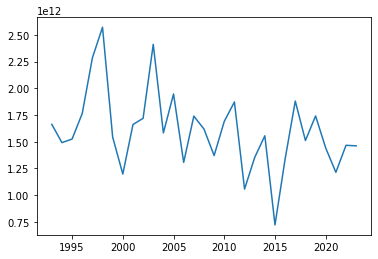

In [53]:
plt.plot(Years,volume[Aprils])


In [ ]:
volume

In [ ]:
plt.plot(Years, volume[Septembers])

In [ ]:
plt.plot(Years, volume[Octobers])

In [ ]:
plt.plot(Years, volume[Augusts])
plt.plot(Years, m*Years+b)

In [56]:
#obtain m (slope) and b(intercept) of linear regression line
m, b = np.polyfit(Years, volume[Augusts], 1)

#add linear regression line to scatterplot 


In [ ]:
import scipy.stats
scipy.stats.pearsonr(Years[:-1], np.nanmean(np.nanmean(mean_cptemp[Augusts,:,:],2),1))

In [55]:
# Create one pandas data frame for Aprils, Julys, and Octobers and save to final timeseries folder
d = {'April': volume[Aprils],
     'May': volume[Mays],
     'June': volume[Junes],
     'July': volume[Julys],
     'August': volume[Augusts],
     'September': volume[Septembers],
     'October': volume[Octobers]}
CP_vol = pn.DataFrame(data = d, index = Years)
#CP_vol.to_csv('/Users/nyelab/Desktop/NYB Indicators/FInal_Timeseries/CP_volume_Dec_6_2021.csv')
CP_vol.to_csv('/Users/nyelab/Desktop/NYB Indicators/NYB_Indicators_Calculations/Final_Timeseries_Figures/Timeseries_Files_2023/CP_volume_Jan_8_2024.csv')

## Everything after this is old stuff and unnecessary for the Inidcator at this time

In [ ]:
onset_month = [2,4,4,4,4,4,3,4,3,4]

In [ ]:
np.where(np.diff(volume[:12])<0)

In [ ]:
c = plt.contourf(glorys.longitude[70:115],glorys.latitude[25:70],d34[16,25:70,70:115])#,levels = np.arange(0,15,1))
plt.colorbar(c)

In [ ]:
c = plt.contourf(glorys.longitude[70:115],glorys.latitude[25:70],d10[16,25:70,70:115])#,levels = np.arange(0,15,1))
plt.colorbar(c)

In [ ]:
plt.imshow(d34[0,:,:])

In [ ]:
test = glorys_nyb_theta[:,:,50,100]

In [ ]:
x = 10
xp = glorys_nyb_theta[0,:,50,100]
y = glorys.depth
yp = np.interp(x,xp,y)
xp

In [ ]:
plt.imshow(glorys_nyb_theta[0,10,25:70,70:115])

In [ ]:
topo = xr.open_dataset("/Users/nyelab/Downloads/ETOPO1_Bed_g_gmt4(1).grd")

In [ ]:
topo

In [ ]:
(glorys.longitude)

In [ ]:
glorys_topo = topo.z[np.arange(7560,7921,5),np.arange(6000,7201,5)]

In [ ]:
c = plt.pcolor(glorys.longitude, glorys.latitude, glorys_topo)
plt.colorbar(c)

In [ ]:
c = plt.imshow((area*(1000*1000))*((-1*glorys_topo) - d10[0,:,:]))
plt.colorbar(c)

In [ ]:
np.shape(d10)

In [ ]:
area


In [ ]:
volume = np.empty(324)
for i in range(324):
    volume[i] = np.nansum((area*(1000*1000))*((-1*glorys_topo) - d10[i,:,:]))

In [ ]:
fig,ax = plt.subplots(figsize = [20,10])
ax.plot(glorys.time, volume, label = 'monthly means')
ax.plot(glorys.time,seasonal, label = 'seasonal cycle')
ax.tick_params(labelsize =14)
ax.set_ylabel('volume m3',fontsize = 16)
ax.set_title('Cool Pool Volume (bounded by 10C)', fontsize = 18)
ax.legend(fontsize = 16)

In [ ]:
fig,ax = plt.subplots(figsize = [20,10])
ax.plot(glorys.time[JJA], volume[JJA])
ax.plot(glorys.time[JJA],seasonal[JJA])
ax.tick_params(labelsize =14)
ax.set_ylabel('volume m3',fontsize = 16)
ax.set_title('Cool Pool Volume (bounded by 10C)', fontsize = 18)

In [ ]:
fig,ax = plt.subplots(figsize = [20,10])
ax.plot(glorys.time[Mar], volume[Mar],c = 'r', label = 'March')
ax.plot(glorys.time[Apr], volume[Apr], c = 'green', label = 'April')
ax.plot(glorys.time[May], volume[May], c = 'b', label = 'May')
ax.plot(glorys.time[Mar],seasonal[Mar], c= 'r', linestyle = '-.')
ax.plot(glorys.time[Apr],seasonal[Apr], c = 'green', linestyle = '-.')
ax.plot(glorys.time[May],seasonal[May], c='b', linestyle = '-.')
ax.tick_params(labelsize =14)
ax.set_ylabel('volume m3',fontsize = 16)
ax.set_title('Cool Pool Volume (bounded by 10C)', fontsize = 18)
ax.legend(fontsize = 16)

In [ ]:
fig,ax = plt.subplots(figsize = [20,10])
ax.plot(glorys.time[Jun], volume[Jun],c = 'r', label = 'June')
ax.plot(glorys.time[Jul], volume[Jul], c = 'green', label = 'July')
ax.plot(glorys.time[Aug], volume[Aug], c = 'b', label = 'August')
ax.plot(glorys.time[Jun],seasonal[Jun], c= 'r', linestyle = '-.')
ax.plot(glorys.time[Jul],seasonal[Jul], c = 'green', linestyle = '-.')
ax.plot(glorys.time[Aug],seasonal[Aug], c='b', linestyle = '-.')
ax.tick_params(labelsize =14)
ax.set_ylabel('volume m3',fontsize = 16)
ax.set_title('Cool Pool Volume (bounded by 10C)', fontsize = 18)
ax.legend(fontsize = 16)

In [ ]:
fig,ax = plt.subplots(figsize = [20,10])
ax.plot(glorys.time[Sep], volume[Sep],c = 'r', label = 'September')
ax.plot(glorys.time[Oct], volume[Oct], c = 'green', label = 'October')
ax.plot(glorys.time[Nov], volume[Nov], c = 'b', label = 'November')
ax.plot(glorys.time[Sep],seasonal[Sep], c= 'r', linestyle = '-.')
ax.plot(glorys.time[Oct],seasonal[Oct], c = 'green', linestyle = '-.')
ax.plot(glorys.time[Nov],seasonal[Nov], c='b', linestyle = '-.')
ax.tick_params(labelsize =14)
ax.set_ylabel('volume m3',fontsize = 16)
ax.set_title('Cool Pool Volume (bounded by 10C)', fontsize = 18)
ax.legend(fontsize = 16)

In [ ]:
np.shape(glorys_nyb_theta)

In [ ]:
for i in range(45,55):
    j = 100
    plt.scatter(glorys.depth, glorys_nyb_theta[0,:,i,j])

In [ ]:
glorys.time

In [ ]:
plt.plot([10,10],[glorys.depth[0],glorys.depth[-1]])

In [ ]:
fig,ax = plt.subplots(nrows = 2, ncols = 2, figsize = [10,10])
for i in range(7):
    ax[0,0].plot(np.nanmean(np.nanmean(glorys_nyb_theta[Aug[i],:,:,:],2),1),glorys.depth,c='r')
    ax[0,0].set_ylim([200,0])
for i in range(8,18):
    ax[0,1].plot(np.nanmean(np.nanmean(glorys_nyb_theta[Aug[i],:,:,:],2),1),glorys.depth,c='r')
    ax[0,1].set_ylim([200,0])
for i in range(18,27):
    ax[1,0].plot(np.nanmean(np.nanmean(glorys_nyb_theta[Aug[i],:,:,:],2),1),glorys.depth,c='r')
    ax[1,0].set_ylim([200,0])
ax[0,0].plot([10,10],[0,200])
ax[0,0].set_ylim([200,0])
ax[0,0].set_title('Aug 1990s')
ax[1,0].plot([10,10],[0,200])
ax[1,0].set_ylim([200,0])
ax[0,1].set_title('Aug 00s')
ax[0,1].plot([10,10],[0,200])
ax[0,1].set_ylim([200,0])
ax[1,0].set_title('Aug 10s')

In [ ]:
fig,ax = plt.subplots(nrows = 2, ncols = 2, figsize = [10,10])
for i in range(7):
    ax[0,0].plot(np.nanmean(np.nanmean(glorys_nyb_theta[Mar[i],:,:,:],2),1),glorys.depth,c='r')
    ax[0,0].set_ylim([200,0])
    ax[0,0].set_xlim([4,14])
for i in range(8,18):
    ax[0,1].plot(np.nanmean(np.nanmean(glorys_nyb_theta[Mar[i],:,:,:],2),1),glorys.depth,c='r')
    ax[0,1].set_ylim([200,0])
    ax[0,1].set_xlim([4,14])
for i in range(18,27):
    ax[1,0].plot(np.nanmean(np.nanmean(glorys_nyb_theta[Mar[i],:,:,:],2),1),glorys.depth,c='r')
    ax[1,0].set_ylim([200,0])
    ax[1,0].set_xlim([4,14])
ax[0,0].plot([10,10],[0,200])
ax[0,0].set_ylim([200,0])
ax[0,0].set_title('Mar 1990s')
ax[1,0].plot([10,10],[0,200])
ax[1,0].set_ylim([200,0])
ax[0,1].set_title('Mar 00s')
ax[0,1].plot([10,10],[0,200])
ax[0,1].set_ylim([200,0])
ax[1,0].set_title('Mar 10s')

In [ ]:
fig,ax = plt.subplots(figsize = [10,10])
for k in range(7):
    for i in range(73):
        for j in range(241):
            ax.plot(glorys_nyb_theta[Aug[k],:,i,j],glorys.depth,c='r')
for k in range(7):
    ax.plot(np.nanmean(np.nanmean(glorys_nyb_theta[Aug[k],:,:,:],2),1),glorys.depth,c='k')
ax.set_ylim([100,0])

In [ ]:
np.shape(d10)

In [ ]:
 
import numpy as np
from mpl_toolkits.mplot3d import axes3d
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
X, Y = np.meshgrid(glorys.longitude, glorys.latitude)
Z = d10[7,:,:]
ax.plot_surface(X, Y, Z, cmap="autumn_r",vmin=np.nanmin(Z), vmax=np.nanmax(Z), lw=0.5, rstride=1, cstride=1, alpha=0.5)
#ax.contour(X, Y, Z, 10, lw=3, cmap="autumn_r", linestyles="solid", offset=-1)
#ax.contour(X, Y, Z, 10, lw=3, colors="k", linestyles="solid")
ax.set_ylim([38, 41])
ax.set_xlim([-73.5,-70])
ax.set_zlim([250,0])
plt.show()

In [ ]:
c = plt.imshow(d10[7,:,:])
plt.colorbar(c)

In [ ]:
plt.scatter(glorys_nyb_theta[Aug[0],:,45,100],glorys.depth,c='r',s = 2)

In [ ]:
vol = xr.Dataset(data_vars = {'volume':('time',volume)}, coords = {'time': ('time',glorys.time)})

In [ ]:
seas = vol.volume.groupby('time.month').mean('time')
seasonal = seas
for i in range(26):
    seasonal = np.append(seasonal,seas)


In [ ]:
JJA = 

In [ ]:
glorys.time

In [ ]:
Mar = np.arange(2,324,12)
Apr = np.arange(3,324,12)
May = np.arange(4,324,12)
Jun = np.arange(5,324,12)
Jul = np.arange(6,324,12)
Aug = np.arange(7,324,12)
Sep = np.arange(8,324,12)
Oct = np.arange(9,324,12)
Nov = np.arange(10,324,12)
fig,ax = plt.subplots(figsize = [10,20])
ax.plot(glorys.time[Apr], volume[Apr],color = 'pink')
ax.plot(glorys.time[May], volume[May], c= 'r')
ax.plot(glorys.time[Jun], volume[Jun], c = 'gold')
ax.plot(glorys.time[Jul], volume[Jul], c= 'orange')
ax.plot(glorys.time[Aug], volume[Aug], c = 'green')
ax.plot(glorys.time[Sep], volume[Sep], c = 'blue')
ax.plot(glorys.time[Oct], volume[Oct], c = 'violet')
ax.tick_params(labelsize =14)
ax.set_ylabel('volume m3',fontsize = 16)
ax.set_title('Cool Pool Volume (bounded by 10C)', fontsize = 18)

In [ ]:
JJA = np.append(Jun,[Jul,Aug])
JJA = np.sort(JJA)

In [ ]:
max(volume)
volume_cp = volume
volume_cp[np.where(volume_cp==max(volume_cp))] = np.nan

In [ ]:
volume_april = volume[np.where(pn.to_datetime(glorys.time.values).month)==4]

In [ ]:
#plt.plot(volume[pn.to_datetime(glorys.time.values).month==4])
plt.plot(volume[pn.to_datetime(glorys.time.values).month==12])

In [ ]:
i=6
c = plt.contourf(glorys.longitude,glorys.latitude,d10[i,:,:],levels = np.arange(0.3,0.8,.01))
plt.title(glorys.time[i].values)
plt.colorbar(c)

In [ ]:


import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)


d10[i,:,:] 

In [ ]:
np.nanmin(d10[i,:,:])

In [ ]:
pn.to_datetime(glorys.time.values).month

In [ ]:
plt.plot(volume_cp)

In [ ]:
area*(1000*1000)

In [ ]:
topo.y[np.arange(7560,7921,5)]

In [ ]:
topo

In [ ]:
np.shape(glorys_nyb_bot_t)

In [ ]:
pn.to_datetime(glorys.time[0].values).dayofyear

In [ ]:
t2 = np.empty(5700132)
t2[:] = np.nan
a=0
for i in range(324):
    for j in range(73):
        for k in range(241):
            te= glorys_nyb_bot_t[i,j,k]
            if te>0:
                t2[a] = str(glorys.time[i].values)
                a=a+1

In [ ]:
temp2 = np.empty(5700132)
temp2[:] = np.nan
lat2 = np.empty(5700132)
lat2[:] = np.nan
lon2 = np.empty(5700132)
lon2[:] = np.nan
t2 = np.empty(5700132)
t2[:] = np.nan
year2 = np.empty(5700132)
year2[:] = np.nan
month2 = np.empty(5700132)
month2[:] = np.nan
day2 = np.empty(5700132)
day2[:] = np.nan
yday2 = np.empty(5700132)
yday2[:] = np.nan
a=0
for i in range(324):
    for j in range(73):
        for k in range(241):
            temp2[a] = glorys_nyb_bot_t[i,j,k]
            if temp2[a]>0:
                lat2[a] = glorys.latitude[j]
                lon2[a] = glorys.longitude[k]
                t2[a] = str(glorys.time[i].values)
                year2[a] = pn.to_datetime(t[a]).year
                month2[a] = pn.to_datetime(t[a]).month
                day2[a] = pn.to_datetime(t[a]).day
                yday2[a] = pn.to_datetime(t[a]).dayofyear
                a=a+1
    print(i)

In [ ]:
plt.plot(temp2)

In [ ]:
bottom_temp = pn.DataFrame({'lon': lon2, 'lat':lat2, 't':t2, 'temp':temp2, 'year': year2, 'month': month2, 'day':day2, 'yday': yday2})

In [ ]:
bottom_temp = bottom_temp[bottom_temp.temp>0]

In [ ]:
bottom_temp